# Авторы – Хожамбетов Ислам и Миробидов Миракбар

## Подключение к базе данных и импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold'
})

# Реквизиты подключения
MY_LOGIN = 'mmirobidov'
MY_PASSWORD = 'Mmirobidov@Db4030'

try:
    conn = psycopg2.connect(
        host='thomas.proxy.rlwy.net',
        port=51432,
        dbname='academy_db',
        user=MY_LOGIN,
        password=MY_PASSWORD,
        sslmode='require'
    )

    def sql(query):
        """Выполнить SQL-запрос и вернуть результат как pandas DataFrame."""
        return pd.read_sql(query, conn)

    print('Подключено к базе данных')

except Exception as e:
    print(f'Не удалось установить соединение: {e}')

Подключено к базе данных


## Гипотеза 
### **Потери MerchantHub от диспутов критически сконцентрированы в узком перечне причин, индустрий и ключевых клиентов?**

## Просмотр Таблиц из базы данных


In [2]:
query_dispute_base = """
WITH dispute_by_txn AS (
    SELECT
        txn_id,
        COUNT(*) AS dispute_records,
        SUM(dispute_amount_uzs) AS disputed_amount_uzs
    FROM public.ds_disputes
    GROUP BY txn_id
),

base AS (
    SELECT
        t.txn_id,
        t.txn_ts,
        t.amount_uzs,
        t.status AS txn_status,
        t.is_cross_region,

        term.terminal_id,

        m.merchant_id,
        m.brand_name,
        m.size_band,
        m.status AS merchant_status,

        mc.category_name,
        mc.risk_tier,

        CASE
            WHEN d.txn_id IS NOT NULL THEN 1
            ELSE 0
        END AS is_disputed,

        COALESCE(d.dispute_records, 0) AS dispute_records,
        COALESCE(d.disputed_amount_uzs, 0) AS disputed_amount_uzs

    FROM public.ds_transactions_1 t

    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id

    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id

    JOIN public.ds_merchant_categories mc
        ON m.category_id = mc.category_id

    LEFT JOIN dispute_by_txn d
        ON t.txn_id = d.txn_id

    WHERE t.status = 'approved'
      AND m.status = 'active'
)

SELECT *
FROM base;
"""

dispute_df = pd.read_sql(query_dispute_base, conn)

dispute_df.head()

,txn_id,txn_ts,amount_uzs,txn_status,is_cross_region,terminal_id,merchant_id,brand_name,size_band,merchant_status,category_name,risk_tier,is_disputed,dispute_records,disputed_amount_uzs
0,1,2025-12-26 07:21:00,1712100,approved,False,529,247,Brand247,medium,active,Gaming,high,0,0,0.0
1,2,2025-10-11 11:05:00,51300,approved,True,2517,1196,Brand1196,large,active,Restaurant,low,0,0,0.0
2,3,2025-09-14 12:16:00,266700,approved,False,1834,874,Brand874,medium,active,OnlineRetail,medium,0,0,0.0
3,4,2025-12-26 17:29:00,652600,approved,False,1630,773,Brand773,small,active,Jewelry,high,0,0,0.0
4,5,2025-11-07 11:23:00,477200,approved,False,1831,874,Brand874,medium,active,OnlineRetail,medium,0,0,0.0


In [3]:
dispute_df.shape

(70543, 15)

In [4]:
dispute_df[["amount_uzs", "is_disputed", "disputed_amount_uzs"]].describe()

,amount_uzs,is_disputed,disputed_amount_uzs
count,7.054300e+04,70543.000000,7.054300e+04
mean,3.257171e+05,0.027345,9.414448e+03
std,4.872447e+05,0.163088,9.950406e+04
min,3.800000e+03,0.000000,0.000000e+00
25%,9.670000e+04,0.000000,0.000000e+00
50%,1.800000e+05,0.000000,0.000000e+00
75%,3.520500e+05,0.000000,0.000000e+00
max,1.613930e+07,1.000000,5.367427e+06


## Первичное исследование данных

In [5]:
dispute_df["risk_tier"].value_counts()

risk_tier
low       51743
medium    11627
high       7173
Name: count, dtype: int64

In [6]:
dispute_df["is_cross_region"].value_counts()

is_cross_region
False    62526
True      8017
Name: count, dtype: int64

In [7]:
total_txns = len(dispute_df)
total_disputed_txns = dispute_df["is_disputed"].sum()
total_turnover = dispute_df["amount_uzs"].sum()
total_disputed_amount = dispute_df["disputed_amount_uzs"].sum()

overall_dispute_rate = total_disputed_txns / total_txns * 100
overall_disputed_amount_share = total_disputed_amount / total_turnover * 100

print("Total successful transactions:", total_txns)
print("Disputed transactions:", total_disputed_txns)
print("Overall dispute rate:", round(overall_dispute_rate, 2), "%")
print("Total turnover:", total_turnover)
print("Total disputed amount:", total_disputed_amount)
print("Disputed amount share:", round(overall_disputed_amount_share, 2), "%")

Total successful transactions: 70543
Disputed transactions: 1929
Overall dispute rate: 2.73 %
Total turnover: 22977058700
Total disputed amount: 664123425.0
Disputed amount share: 2.89 %


In [8]:
risk_summary = (
    dispute_df
    .groupby("risk_tier")
    .agg(
        txn_count=("txn_id", "count"),
        disputed_txn_count=("is_disputed", "sum"),
        turnover_uzs=("amount_uzs", "sum"),
        disputed_amount_uzs=("disputed_amount_uzs", "sum")
    )
    .reset_index()
)

risk_summary["dispute_rate_pct"] = (
    risk_summary["disputed_txn_count"] / risk_summary["txn_count"] * 100
)

risk_summary["disputed_amount_share_pct"] = (
    risk_summary["disputed_amount_uzs"] / risk_summary["turnover_uzs"] * 100
)

risk_summary = risk_summary.sort_values("dispute_rate_pct", ascending=False)

risk_summary

,risk_tier,txn_count,disputed_txn_count,turnover_uzs,disputed_amount_uzs,dispute_rate_pct,disputed_amount_share_pct
0,high,7173,437,8318342800,386409414.0,6.092291,4.645269
2,medium,11627,321,4660257400,101849771.0,2.760815,2.185497
1,low,51743,1171,9998458500,175864240.0,2.263108,1.758914


In [9]:
cross_region_summary = (
    dispute_df
    .groupby("is_cross_region")
    .agg(
        txn_count=("txn_id", "count"),
        disputed_txn_count=("is_disputed", "sum"),
        turnover_uzs=("amount_uzs", "sum"),
        disputed_amount_uzs=("disputed_amount_uzs", "sum")
    )
    .reset_index()
)

cross_region_summary["dispute_rate_pct"] = (
    cross_region_summary["disputed_txn_count"] / cross_region_summary["txn_count"] * 100
)

cross_region_summary["disputed_amount_share_pct"] = (
    cross_region_summary["disputed_amount_uzs"] / cross_region_summary["turnover_uzs"] * 100
)

cross_region_summary

,is_cross_region,txn_count,disputed_txn_count,turnover_uzs,disputed_amount_uzs,dispute_rate_pct,disputed_amount_share_pct
0,False,62526,1693,18946231400,543489193.0,2.707674,2.868587
1,True,8017,236,4030827300,120634232.0,2.943745,2.992791


In [10]:
category_summary = (
    dispute_df
    .groupby(["category_name", "risk_tier"])
    .agg(
        txn_count=("txn_id", "count"),
        disputed_txn_count=("is_disputed", "sum"),
        turnover_uzs=("amount_uzs", "sum"),
        disputed_amount_uzs=("disputed_amount_uzs", "sum")
    )
    .reset_index()
)

category_summary["dispute_rate_pct"] = (
    category_summary["disputed_txn_count"] / category_summary["txn_count"] * 100
)

category_summary["disputed_amount_share_pct"] = (
    category_summary["disputed_amount_uzs"] / category_summary["turnover_uzs"] * 100
)

category_summary = category_summary.sort_values("dispute_rate_pct", ascending=False)

category_summary.head(15)

,category_name,risk_tier,txn_count,disputed_txn_count,turnover_uzs,disputed_amount_uzs,dispute_rate_pct,disputed_amount_share_pct
16,Travel,high,2443,172,2951317000,160236731.0,7.040524,5.429330
7,Jewelry,high,1791,106,2263838000,107246201.0,5.918481,4.737362
6,Hotel,high,2157,120,2368823900,86839532.0,5.563282,3.665934
5,Gaming,high,782,39,734363900,32086950.0,4.987212,4.369353
9,OnlineRetail,medium,4897,158,2046057900,54970607.0,3.226465,2.686659
8,Marketplace,medium,2126,61,845154100,17697479.0,2.869238,2.093994
11,Pharmacy,low,4081,105,807184900,15955523.0,2.572899,1.976687
17,Utilities,low,2590,63,494648400,9000672.0,2.432432,1.819610
12,Restaurant,low,11131,262,2374140400,45647929.0,2.353787,1.922714
15,Transport,low,5487,129,1091469100,21028252.0,2.351011,1.926601


In [11]:
category_summary_filtered = category_summary[category_summary["txn_count"] >= 100]

category_summary_filtered.sort_values("dispute_rate_pct", ascending=False).head(10)

,category_name,risk_tier,txn_count,disputed_txn_count,turnover_uzs,disputed_amount_uzs,dispute_rate_pct,disputed_amount_share_pct
16,Travel,high,2443,172,2951317000,160236731.0,7.040524,5.429330
7,Jewelry,high,1791,106,2263838000,107246201.0,5.918481,4.737362
6,Hotel,high,2157,120,2368823900,86839532.0,5.563282,3.665934
5,Gaming,high,782,39,734363900,32086950.0,4.987212,4.369353
9,OnlineRetail,medium,4897,158,2046057900,54970607.0,3.226465,2.686659
8,Marketplace,medium,2126,61,845154100,17697479.0,2.869238,2.093994
11,Pharmacy,low,4081,105,807184900,15955523.0,2.572899,1.976687
17,Utilities,low,2590,63,494648400,9000672.0,2.432432,1.819610
12,Restaurant,low,11131,262,2374140400,45647929.0,2.353787,1.922714
15,Transport,low,5487,129,1091469100,21028252.0,2.351011,1.926601


In [12]:
query_status = """
SELECT
    status,
    COUNT(*) AS disputes
FROM public.ds_disputes
GROUP BY status
ORDER BY disputes DESC;
"""

status_df = pd.read_sql(query_status, conn)

status_df

,status,disputes
0,lost,879
1,won,803
2,open,304


In [13]:
query_status = """
SELECT
    status,
    COUNT(*) AS disputes,
    SUM(dispute_amount_uzs) AS disputed_amount_uzs,
    AVG(dispute_amount_uzs) AS avg_dispute_amount_uzs
FROM public.ds_disputes
GROUP BY status
ORDER BY disputed_amount_uzs DESC;
"""

status_df = pd.read_sql(query_status, conn)

status_df

,status,disputes,disputed_amount_uzs,avg_dispute_amount_uzs
0,won,803,298508134.0,371741.138232
1,lost,879,281304975.0,320028.412969
2,open,304,97438248.0,320520.552632


## Графики для понимания данных

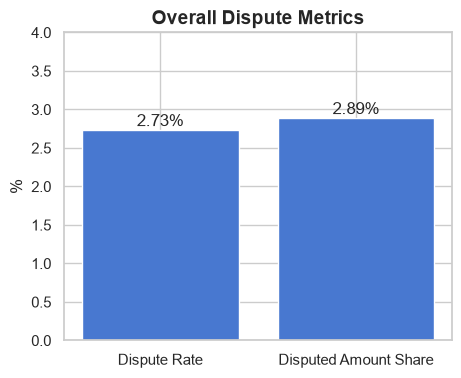

In [14]:
metrics = ['Dispute Rate', 'Disputed Amount Share']
values = [overall_dispute_rate, overall_disputed_amount_share]

plt.figure(figsize=(5,4))
plt.bar(metrics, values)
plt.ylabel('%')
plt.title('Overall Dispute Metrics')

for i,v in enumerate(values):
    plt.text(i, v+0.05, f'{v:.2f}%', ha='center')

plt.ylim(0,4)
plt.show()

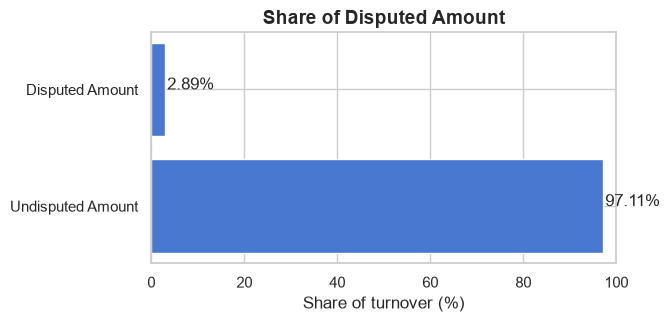

In [15]:
labels = ['Undisputed Amount', 'Disputed Amount']
values = [100-overall_disputed_amount_share,
          overall_disputed_amount_share]

plt.figure(figsize=(6,3))
plt.barh(labels, values)
plt.xlabel("Share of turnover (%)")
plt.title("Share of Disputed Amount")
plt.xlim(0,100)

for i,v in enumerate(values):
    plt.text(v+0.5, i, f"{v:.2f}%")

plt.show()

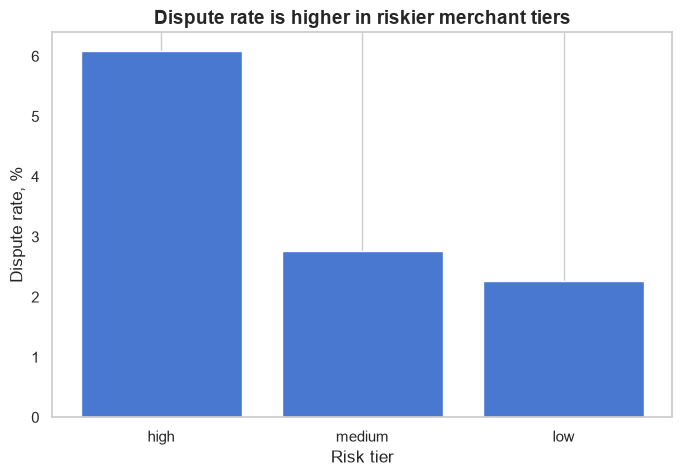

In [16]:
plot_df = risk_summary.sort_values("dispute_rate_pct", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["risk_tier"], plot_df["dispute_rate_pct"])

plt.title("Dispute rate is higher in riskier merchant tiers")
plt.xlabel("Risk tier")
plt.ylabel("Dispute rate, %")
plt.grid(axis="y")

plt.show()

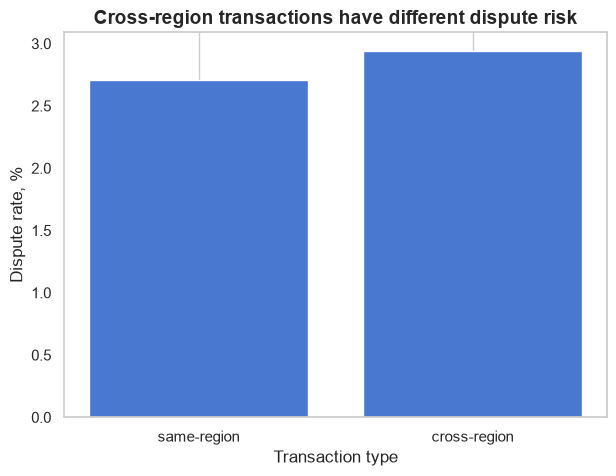

In [17]:
plot_df = cross_region_summary.copy()

plot_df["cross_region_label"] = plot_df["is_cross_region"].map({
    True: "cross-region",
    False: "same-region"
})

plt.figure(figsize=(7, 5))
plt.bar(plot_df["cross_region_label"], plot_df["dispute_rate_pct"])

plt.title("Cross-region transactions have different dispute risk")
plt.xlabel("Transaction type")
plt.ylabel("Dispute rate, %")
plt.grid(axis="y")

plt.show()

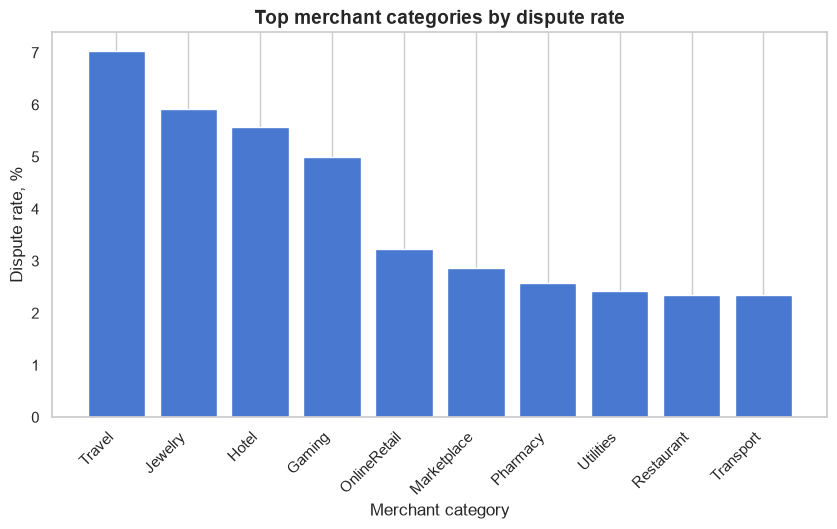

In [18]:
top_categories = (
    category_summary_filtered
    .sort_values("dispute_rate_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(top_categories["category_name"], top_categories["dispute_rate_pct"])

plt.title("Top merchant categories by dispute rate")
plt.xlabel("Merchant category")
plt.ylabel("Dispute rate, %")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

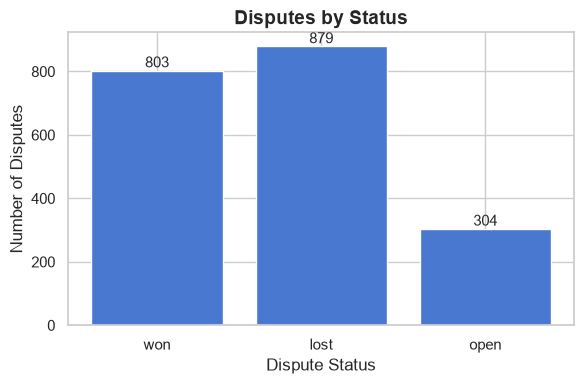

In [19]:
plt.figure(figsize=(6,4))

bars = plt.bar(status_df["status"], status_df["disputes"])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=11
    )

plt.title("Disputes by Status")
plt.xlabel("Dispute Status")
plt.ylabel("Number of Disputes")

plt.tight_layout()
plt.show()

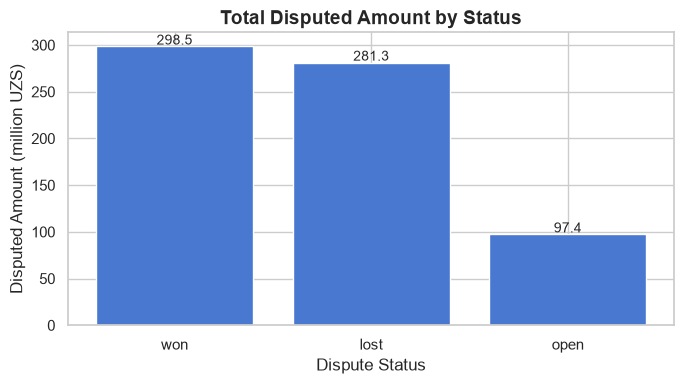

In [20]:
plt.figure(figsize=(7,4))

bars = plt.bar(
    status_df["status"],
    status_df["disputed_amount_uzs"] / 1e6
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{bar.get_height():.1f}",
        ha="center",
        fontsize=10
    )

plt.title("Total Disputed Amount by Status")
plt.xlabel("Dispute Status")
plt.ylabel("Disputed Amount (million UZS)")

plt.tight_layout()
plt.show()

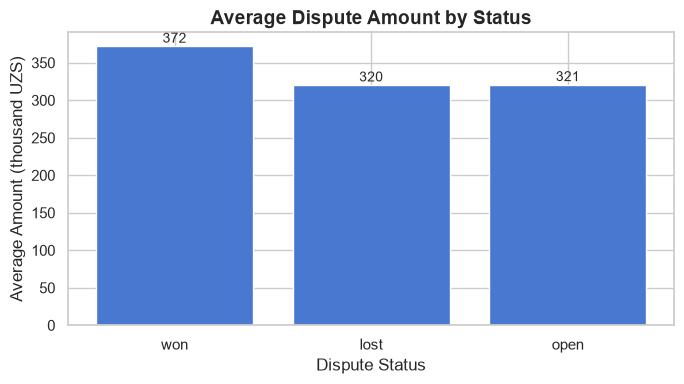

In [21]:
plt.figure(figsize=(7,4))

bars = plt.bar(
    status_df["status"],
    status_df["avg_dispute_amount_uzs"] / 1000
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f"{bar.get_height():.0f}",
        ha="center",
        fontsize=10
    )

plt.title("Average Dispute Amount by Status")
plt.xlabel("Dispute Status")
plt.ylabel("Average Amount (thousand UZS)")

plt.tight_layout()
plt.show()

In [22]:
same_region_rate = cross_region_summary.loc[
    cross_region_summary["is_cross_region"] == False,
    "dispute_rate_pct"
].iloc[0]

cross_region_rate = cross_region_summary.loc[
    cross_region_summary["is_cross_region"] == True,
    "dispute_rate_pct"
].iloc[0]

risk_ratio = cross_region_rate / same_region_rate

print("Same-region dispute rate:", round(same_region_rate, 2), "%")
print("Cross-region dispute rate:", round(cross_region_rate, 2), "%")
print("Risk ratio:", round(risk_ratio, 2))

Same-region dispute rate: 2.71 %
Cross-region dispute rate: 2.94 %
Risk ratio: 1.09


## Очень Детальний Анализ

In [23]:
pd.read_sql("""
SELECT
    dispute_type,
    reason_code,
    COUNT(*) AS cnt,
    SUM(dispute_amount_uzs) AS disputed_amount_uzs
FROM public.ds_disputes
GROUP BY dispute_type, reason_code
ORDER BY cnt DESC;
""", conn)

,dispute_type,reason_code,cnt,disputed_amount_uzs
0,chargeback,product_not_received,441,108914180.0
1,chargeback,quality,328,89014565.0
2,retrieval_request,product_not_received,211,46128088.0
3,chargeback,subscription_cancel,166,45582266.0
4,retrieval_request,quality,158,44126623.0
5,chargeback,duplicate,143,42631836.0
6,chargeback,fraud,130,145157477.0
7,retrieval_request,subscription_cancel,88,27967867.0
8,retrieval_request,duplicate,84,20950834.0
9,pre_arbitration,product_not_received,71,16896015.0


In [24]:
query_dispute_reason = """
WITH dispute_base AS (
    SELECT
        d.dispute_id,
        d.txn_id,
        d.opened_date,
        d.reason_code,
        d.dispute_type,
        d.dispute_amount_uzs,
        d.status AS dispute_status,
        d.resolved_date,

        t.txn_ts,
        t.amount_uzs,
        t.is_cross_region,

        m.merchant_id,
        m.brand_name,
        m.size_band,
        m.status AS merchant_status,

        mc.category_name,
        mc.risk_tier

    FROM public.ds_disputes d

    JOIN public.ds_transactions_1 t
        ON d.txn_id = t.txn_id

    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id

    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id

    JOIN public.ds_merchant_categories mc
        ON m.category_id = mc.category_id

    WHERE t.status = 'approved'
      AND m.status = 'active'
)

SELECT
    dispute_type,
    reason_code,

    COUNT(*) AS dispute_count,
    COUNT(DISTINCT txn_id) AS disputed_txn_count,

    SUM(dispute_amount_uzs) AS disputed_amount_uzs,
    ROUND(AVG(dispute_amount_uzs)::numeric, 2) AS avg_dispute_amount_uzs,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY dispute_amount_uzs)::numeric, 2) AS median_dispute_amount_uzs,

    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS dispute_count_share_pct,

    ROUND(
        100.0 * SUM(dispute_amount_uzs) / SUM(SUM(dispute_amount_uzs)) OVER (),
        2
    ) AS disputed_amount_share_pct

FROM dispute_base
GROUP BY
    dispute_type,
    reason_code
ORDER BY disputed_amount_uzs DESC;
"""

dispute_reason_df = pd.read_sql(query_dispute_reason, conn)

dispute_reason_df

,dispute_type,reason_code,dispute_count,disputed_txn_count,disputed_amount_uzs,avg_dispute_amount_uzs,median_dispute_amount_uzs,dispute_count_share_pct,disputed_amount_share_pct
0,chargeback,fraud,129,129,144502795.0,1120176.71,901402.0,6.69,21.76
1,chargeback,product_not_received,432,432,107209363.0,248169.82,146005.0,22.40,16.14
2,chargeback,quality,318,318,87751185.0,275947.12,152728.5,16.49,13.21
3,retrieval_request,fraud,57,57,50941405.0,893708.86,654232.0,2.95,7.67
4,chargeback,subscription_cancel,163,163,45170080.0,277117.06,146100.0,8.45,6.80
5,retrieval_request,product_not_received,201,201,44295088.0,220373.57,135044.0,10.42,6.67
6,retrieval_request,quality,150,150,43010064.0,286733.76,138492.5,7.78,6.48
7,chargeback,duplicate,141,141,42034187.0,298114.80,153377.0,7.31,6.33
8,retrieval_request,subscription_cancel,85,85,24926939.0,293258.11,148746.0,4.41,3.75
9,retrieval_request,duplicate,79,79,19277482.0,244018.76,140833.0,4.10,2.90


In [25]:
dispute_reason_df.sort_values(
    "dispute_count",
    ascending=False
).head(10)

,dispute_type,reason_code,dispute_count,disputed_txn_count,disputed_amount_uzs,avg_dispute_amount_uzs,median_dispute_amount_uzs,dispute_count_share_pct,disputed_amount_share_pct
1,chargeback,product_not_received,432,432,107209363.0,248169.82,146005.0,22.40,16.14
2,chargeback,quality,318,318,87751185.0,275947.12,152728.5,16.49,13.21
5,retrieval_request,product_not_received,201,201,44295088.0,220373.57,135044.0,10.42,6.67
4,chargeback,subscription_cancel,163,163,45170080.0,277117.06,146100.0,8.45,6.80
6,retrieval_request,quality,150,150,43010064.0,286733.76,138492.5,7.78,6.48
7,chargeback,duplicate,141,141,42034187.0,298114.80,153377.0,7.31,6.33
0,chargeback,fraud,129,129,144502795.0,1120176.71,901402.0,6.69,21.76
8,retrieval_request,subscription_cancel,85,85,24926939.0,293258.11,148746.0,4.41,3.75
9,retrieval_request,duplicate,79,79,19277482.0,244018.76,140833.0,4.10,2.90
10,pre_arbitration,product_not_received,67,67,16240722.0,242398.84,149389.0,3.47,2.45


In [26]:
dispute_reason_df.sort_values(
    "disputed_amount_uzs",
    ascending=False
).head(10)

,dispute_type,reason_code,dispute_count,disputed_txn_count,disputed_amount_uzs,avg_dispute_amount_uzs,median_dispute_amount_uzs,dispute_count_share_pct,disputed_amount_share_pct
0,chargeback,fraud,129,129,144502795.0,1120176.71,901402.0,6.69,21.76
1,chargeback,product_not_received,432,432,107209363.0,248169.82,146005.0,22.40,16.14
2,chargeback,quality,318,318,87751185.0,275947.12,152728.5,16.49,13.21
3,retrieval_request,fraud,57,57,50941405.0,893708.86,654232.0,2.95,7.67
4,chargeback,subscription_cancel,163,163,45170080.0,277117.06,146100.0,8.45,6.80
5,retrieval_request,product_not_received,201,201,44295088.0,220373.57,135044.0,10.42,6.67
6,retrieval_request,quality,150,150,43010064.0,286733.76,138492.5,7.78,6.48
7,chargeback,duplicate,141,141,42034187.0,298114.80,153377.0,7.31,6.33
8,retrieval_request,subscription_cancel,85,85,24926939.0,293258.11,148746.0,4.41,3.75
9,retrieval_request,duplicate,79,79,19277482.0,244018.76,140833.0,4.10,2.90


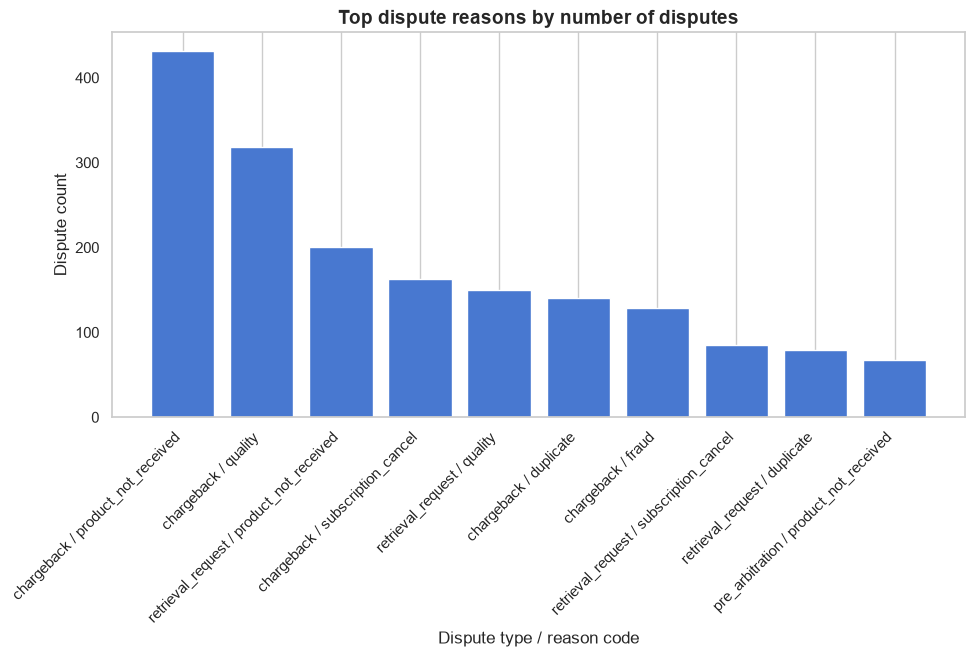

In [27]:
top_reason_count = (
    dispute_reason_df
    .sort_values("dispute_count", ascending=False)
    .head(10)
    .copy()
)

top_reason_count["label"] = (
    top_reason_count["dispute_type"].astype(str)
    + " / "
    + top_reason_count["reason_code"].astype(str)
)

plt.figure(figsize=(11, 5))
plt.bar(top_reason_count["label"], top_reason_count["dispute_count"])

plt.title("Top dispute reasons by number of disputes")
plt.xlabel("Dispute type / reason code")
plt.ylabel("Dispute count")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

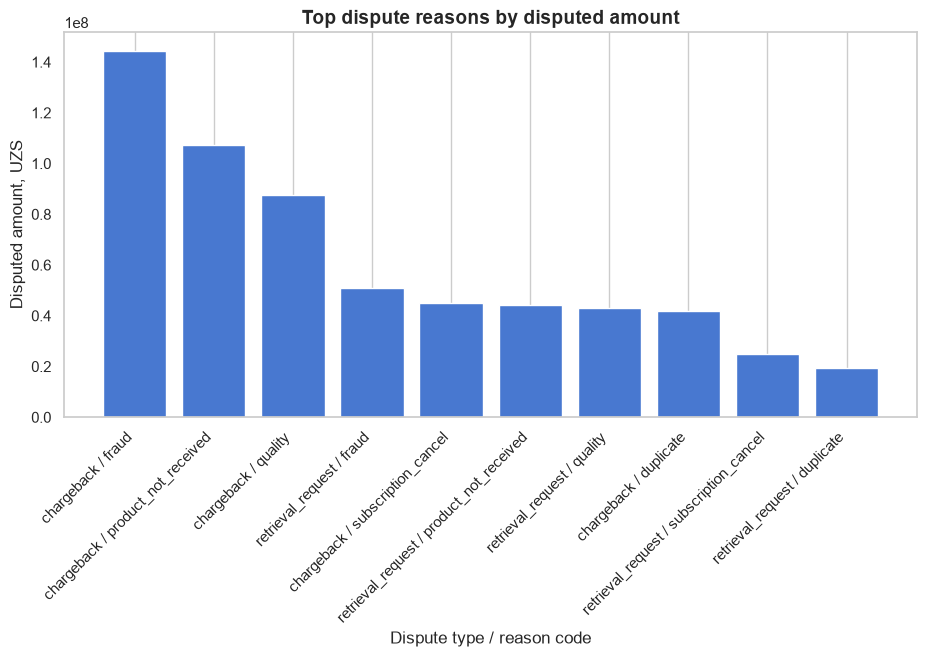

In [28]:
top_reason_amount = (
    dispute_reason_df
    .sort_values("disputed_amount_uzs", ascending=False)
    .head(10)
    .copy()
)

top_reason_amount["label"] = (
    top_reason_amount["dispute_type"].astype(str)
    + " / "
    + top_reason_amount["reason_code"].astype(str)
)

plt.figure(figsize=(11, 5))
plt.bar(top_reason_amount["label"], top_reason_amount["disputed_amount_uzs"])

plt.title("Top dispute reasons by disputed amount")
plt.xlabel("Dispute type / reason code")
plt.ylabel("Disputed amount, UZS")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

In [29]:
query_reason_code = """
WITH total_txns AS (
    SELECT
        COUNT(*) AS total_success_txns,
        SUM(t.amount_uzs) AS total_turnover_uzs
    FROM public.ds_transactions_1 t
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id
    WHERE t.status = 'success'
      AND m.status = 'approved'
),

dispute_base AS (
    SELECT
        d.dispute_id,
        d.txn_id,
        d.reason_code,
        d.dispute_amount_uzs,

        t.amount_uzs,
        t.is_cross_region,

        m.merchant_id,
        m.size_band,

        mc.category_name,
        mc.risk_tier

    FROM public.ds_disputes d

    JOIN public.ds_transactions_1 t
        ON d.txn_id = t.txn_id

    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id

    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id

    JOIN public.ds_merchant_categories mc
        ON m.category_id = mc.category_id

    WHERE t.status = 'approved'
      AND m.status = 'active'
)

SELECT
    d.reason_code,

    COUNT(DISTINCT d.dispute_id) AS dispute_count,
    COUNT(DISTINCT d.txn_id) AS disputed_txn_count,

    SUM(d.dispute_amount_uzs) AS disputed_amount_uzs,
    ROUND(AVG(d.dispute_amount_uzs)::numeric, 2) AS avg_dispute_amount_uzs,

    ROUND(
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY d.dispute_amount_uzs)::numeric,
        2
    ) AS median_dispute_amount_uzs,

    ROUND(
        100.0 * COUNT(DISTINCT d.dispute_id)
        / NULLIF(SUM(COUNT(DISTINCT d.dispute_id)) OVER (), 0),
        2
    ) AS dispute_count_share_pct,

    ROUND(
        100.0 * SUM(d.dispute_amount_uzs)
        / NULLIF(SUM(SUM(d.dispute_amount_uzs)) OVER (), 0),
        2
    ) AS disputed_amount_share_pct,

    ROUND(
        100.0 * COUNT(DISTINCT d.txn_id)
        / NULLIF(tx.total_success_txns, 0),
        4
    ) AS dispute_incidence_pct,

    ROUND(
        100.0 * SUM(d.dispute_amount_uzs)
        / NULLIF(tx.total_turnover_uzs, 0),
        4
    ) AS disputed_amount_to_turnover_pct

FROM dispute_base d
CROSS JOIN total_txns tx

GROUP BY
    d.reason_code,
    tx.total_success_txns,
    tx.total_turnover_uzs

ORDER BY disputed_amount_uzs DESC;
"""

reason_code_df = pd.read_sql(query_reason_code, conn)

reason_code_df

,reason_code,dispute_count,disputed_txn_count,disputed_amount_uzs,avg_dispute_amount_uzs,median_dispute_amount_uzs,dispute_count_share_pct,disputed_amount_share_pct,dispute_incidence_pct,disputed_amount_to_turnover_pct
0,fraud,199,199,208062785.0,1045541.63,807470.0,10.32,31.33,None,None
1,product_not_received,700,700,167745173.0,239635.96,144147.5,36.29,25.26,None,None
2,quality,522,522,143918326.0,275705.61,140272.5,27.06,21.67,None,None
3,subscription_cancel,263,263,73698214.0,280221.35,149304.0,13.63,11.10,None,None
4,duplicate,245,245,70698927.0,288567.05,149988.0,12.70,10.65,None,None


In [30]:
reason_code_df = reason_code_df.sort_values("disputed_amount_uzs", ascending=False).copy()

reason_code_df["cumulative_amount_share_pct"] = (
    reason_code_df["disputed_amount_uzs"].cumsum()
    / reason_code_df["disputed_amount_uzs"].sum()
    * 100
)

reason_code_df["cumulative_count_share_pct"] = (
    reason_code_df["dispute_count"].cumsum()
    / reason_code_df["dispute_count"].sum()
    * 100
)

reason_code_df

,reason_code,dispute_count,disputed_txn_count,disputed_amount_uzs,avg_dispute_amount_uzs,median_dispute_amount_uzs,dispute_count_share_pct,disputed_amount_share_pct,dispute_incidence_pct,disputed_amount_to_turnover_pct,cumulative_amount_share_pct,cumulative_count_share_pct
0,fraud,199,199,208062785.0,1045541.63,807470.0,10.32,31.33,None,None,31.328933,10.316226
1,product_not_received,700,700,167745173.0,239635.96,144147.5,36.29,25.26,None,None,56.587066,46.604458
2,quality,522,522,143918326.0,275705.61,140272.5,27.06,21.67,None,None,78.257484,73.665111
3,subscription_cancel,263,263,73698214.0,280221.35,149304.0,13.63,11.10,None,None,89.354550,87.299119
4,duplicate,245,245,70698927.0,288567.05,149988.0,12.70,10.65,None,None,100.000000,100.000000


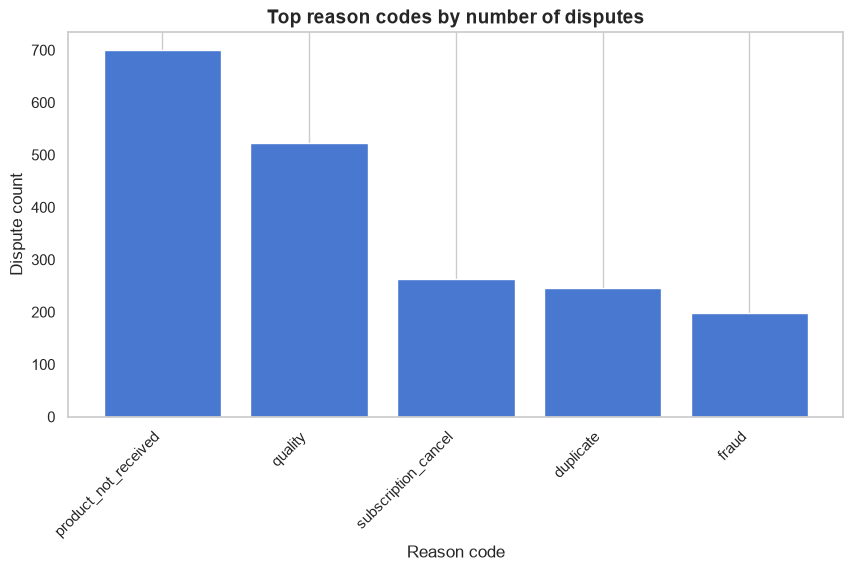

In [31]:
plot_df = reason_code_df.sort_values("dispute_count", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["reason_code"], plot_df["dispute_count"])

plt.title("Top reason codes by number of disputes")
plt.xlabel("Reason code")
plt.ylabel("Dispute count")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

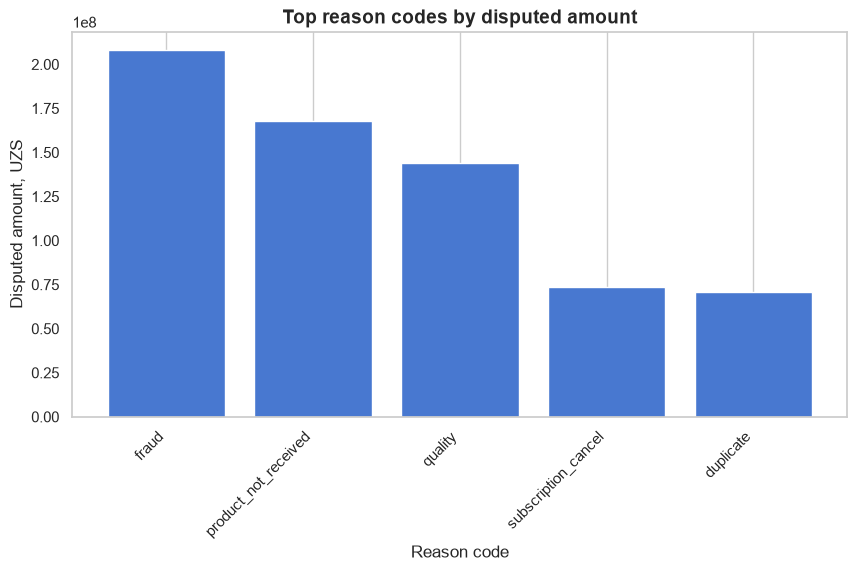

In [32]:
plot_df = reason_code_df.sort_values("disputed_amount_uzs", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["reason_code"], plot_df["disputed_amount_uzs"])

plt.title("Top reason codes by disputed amount")
plt.xlabel("Reason code")
plt.ylabel("Disputed amount, UZS")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

In [33]:
query_reason_code_category = """
WITH dispute_base AS (
    SELECT
        d.dispute_id,
        d.txn_id,
        d.reason_code,
        d.dispute_amount_uzs,

        m.merchant_id,
        m.size_band,

        mc.category_name,
        mc.risk_tier

    FROM public.ds_disputes d

    JOIN public.ds_transactions_1 t
        ON d.txn_id = t.txn_id

    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id

    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id

    JOIN public.ds_merchant_categories mc
        ON m.category_id = mc.category_id

    WHERE t.status = 'approved'
      AND m.status = 'active'
)

SELECT
    reason_code,
    category_name,
    risk_tier,

    COUNT(DISTINCT dispute_id) AS dispute_count,
    SUM(dispute_amount_uzs) AS disputed_amount_uzs,

    ROUND(
        100.0 * SUM(dispute_amount_uzs) / SUM(SUM(dispute_amount_uzs)) OVER (),
        2
    ) AS total_disputed_amount_share_pct

FROM dispute_base

GROUP BY
    reason_code,
    category_name,
    risk_tier

ORDER BY disputed_amount_uzs DESC;
"""

reason_code_category_df = pd.read_sql(query_reason_code_category, conn)

reason_code_category_df.head(15)

,reason_code,category_name,risk_tier,dispute_count,disputed_amount_uzs,total_disputed_amount_share_pct
0,fraud,Travel,high,74,83814025.0,12.62
1,fraud,Jewelry,high,53,60143950.0,9.06
2,fraud,Hotel,high,56,51423632.0,7.74
3,quality,Travel,high,33,28097611.0,4.23
4,product_not_received,OnlineRetail,medium,80,26600854.0,4.01
5,product_not_received,Travel,high,36,21799791.0,3.28
6,quality,Jewelry,high,19,18607290.0,2.80
7,quality,Restaurant,low,91,16230549.0,2.44
8,product_not_received,Electronics,medium,50,15275148.0,2.30
9,product_not_received,Hotel,high,36,14986200.0,2.26


In [34]:
query_reason_code_cross_region = """
WITH dispute_base AS (
    SELECT
        d.dispute_id,
        d.txn_id,
        d.reason_code,
        d.dispute_amount_uzs,

        t.is_cross_region

    FROM public.ds_disputes d

    JOIN public.ds_transactions_1 t
        ON d.txn_id = t.txn_id

    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id

    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id

    WHERE t.status = 'approved'
      AND m.status = 'active'
)

SELECT
    reason_code,
    is_cross_region,

    COUNT(DISTINCT dispute_id) AS dispute_count,
    SUM(dispute_amount_uzs) AS disputed_amount_uzs,

    ROUND(
        100.0 * COUNT(DISTINCT dispute_id)
        / SUM(COUNT(DISTINCT dispute_id)) OVER (PARTITION BY is_cross_region),
        2
    ) AS share_inside_cross_region_group_pct

FROM dispute_base

GROUP BY
    reason_code,
    is_cross_region

ORDER BY
    is_cross_region DESC,
    disputed_amount_uzs DESC;
"""

reason_code_cross_region_df = pd.read_sql(query_reason_code_cross_region, conn)

reason_code_cross_region_df

,reason_code,is_cross_region,dispute_count,disputed_amount_uzs,share_inside_cross_region_group_pct
0,fraud,True,59,71133215.0,25.00
1,product_not_received,True,59,16995377.0,25.00
2,quality,True,53,14593485.0,22.46
3,subscription_cancel,True,36,10015692.0,15.25
4,duplicate,True,29,7896463.0,12.29
5,product_not_received,False,641,150749796.0,37.86
6,fraud,False,140,136929570.0,8.27
7,quality,False,469,129324841.0,27.70
8,subscription_cancel,False,227,63682522.0,13.41
9,duplicate,False,216,62802464.0,12.76


In [35]:
query_status_reason = """
SELECT
    status,
    reason_code,
    COUNT(*) AS disputes,
    SUM(dispute_amount_uzs) AS disputed_amount_uzs
FROM public.ds_disputes
GROUP BY
    status,
    reason_code
ORDER BY
    status,
    disputed_amount_uzs DESC;
"""

status_reason_df = pd.read_sql(query_status_reason, conn)

status_reason_df

,status,reason_code,disputes,disputed_amount_uzs
0,lost,fraud,73,78275086.0
1,lost,product_not_received,325,75814014.0
2,lost,quality,245,60099127.0
3,lost,duplicate,111,36614733.0
4,lost,subscription_cancel,125,30502015.0
5,open,product_not_received,119,30881778.0
6,open,fraud,32,29509142.0
7,open,quality,74,19507837.0
8,open,subscription_cancel,43,9377315.0
9,open,duplicate,36,8162176.0


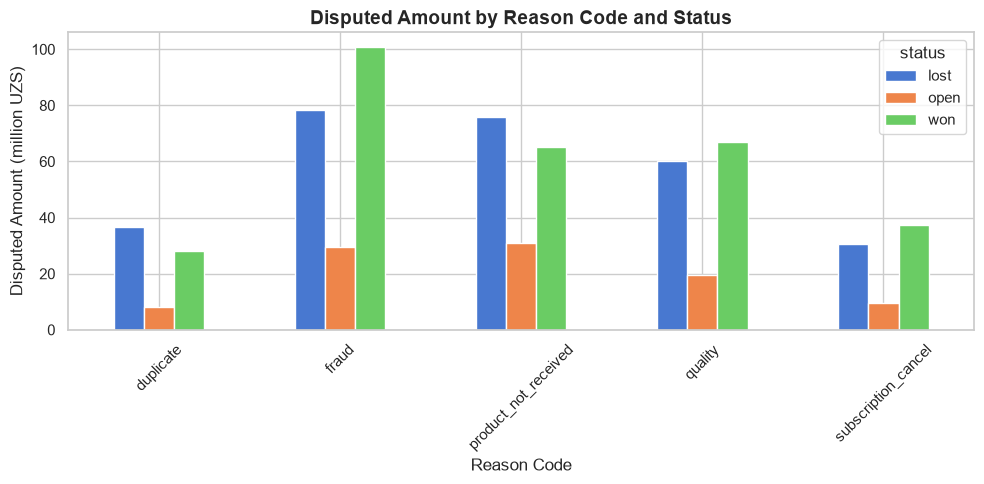

In [36]:
pivot_amount = status_reason_df.pivot(
    index="reason_code",
    columns="status",
    values="disputed_amount_uzs"
).fillna(0)

pivot_amount = pivot_amount / 1e6

pivot_amount.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Disputed Amount by Reason Code and Status")
plt.xlabel("Reason Code")
plt.ylabel("Disputed Amount (million UZS)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [37]:
query_lost_reason = """
SELECT
    reason_code,
    COUNT(*) AS lost_disputes,
    SUM(dispute_amount_uzs) AS lost_amount
FROM public.ds_disputes
WHERE status = 'lost'
GROUP BY reason_code
ORDER BY lost_amount DESC;
"""

lost_reason_df = pd.read_sql(query_lost_reason, conn)

lost_reason_df

,reason_code,lost_disputes,lost_amount
0,fraud,73,78275086.0
1,product_not_received,325,75814014.0
2,quality,245,60099127.0
3,duplicate,111,36614733.0
4,subscription_cancel,125,30502015.0


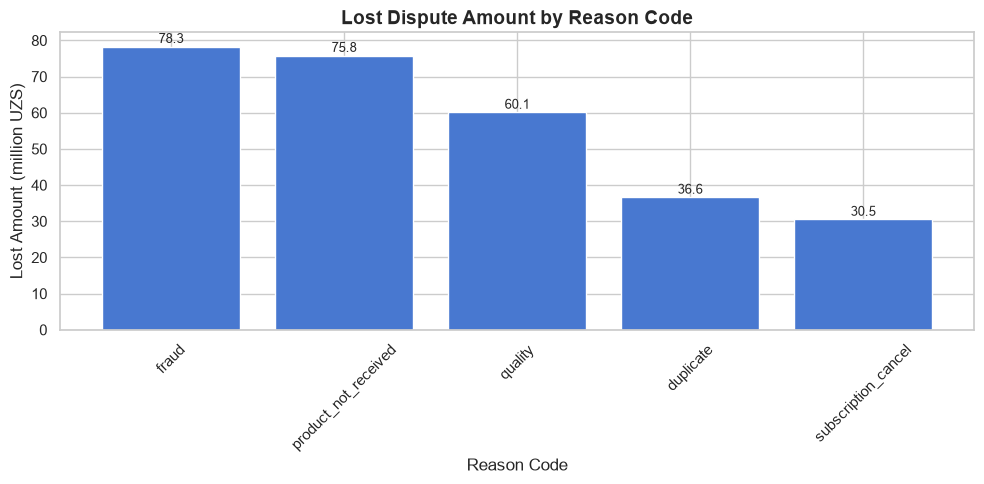

In [38]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    lost_reason_df["reason_code"],
    lost_reason_df["lost_amount"] / 1e6
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}",
        ha="center",
        fontsize=9
    )

plt.title("Lost Dispute Amount by Reason Code")
plt.xlabel("Reason Code")
plt.ylabel("Lost Amount (million UZS)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

findfont: Failed to find font weight medium, now using 400.


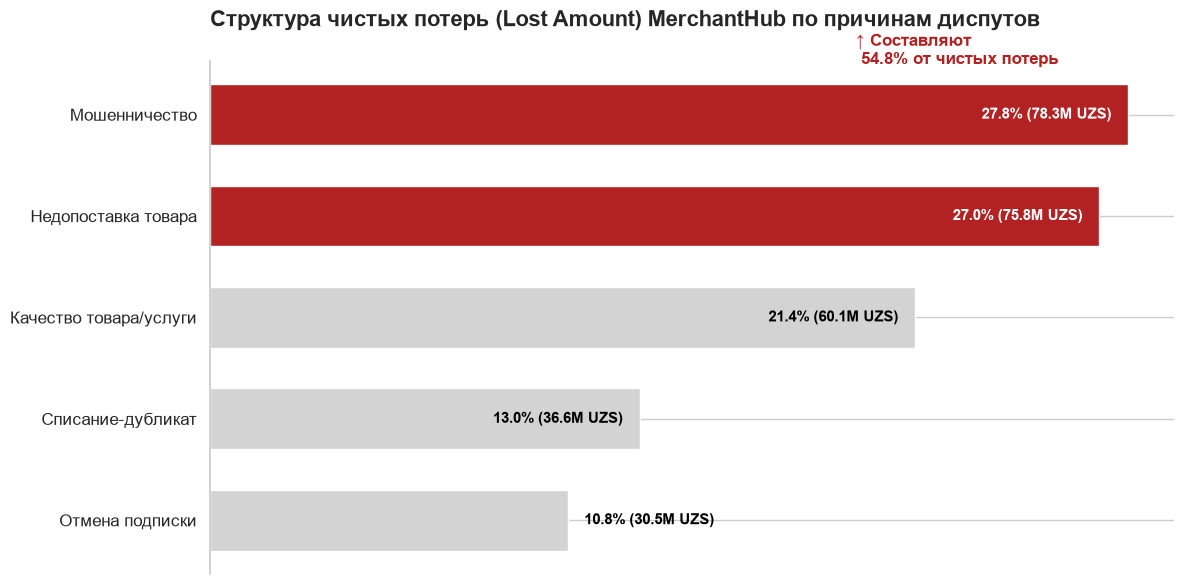

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

df = lost_reason_df.copy()

# Словарь для перевода кодов на русский язык
reason_translation = {
    'fraud': 'Мошенничество',
    'product_not_received': 'Недопоставка товара',
    'quality': 'Качество товара/услуги',
    'subscription_cancel': 'Отмена подписки',
    'duplicate': 'Списание-дубликат'
}
df['reason_ru'] = df['reason_code'].map(reason_translation)

total_lost = df['lost_amount'].sum()
df['lost_share_pct'] = (df['lost_amount'] / total_lost) * 100

# Сортируем по возрастанию долей (чтобы самые крупные категории на barh отображались сверху)
df = df.sort_values(by='lost_share_pct', ascending=True)

# Задаем фокусные цвета для ключевых триггеров рисков
colors = ['lightgrey' if code not in ['fraud', 'product_not_received'] else 'firebrick'
          for code in df['reason_code']]

fig, ax = plt.subplots(figsize=(12, 6))

# Строим горизонтальный барчарт на основе реальных долей чистых убытков
bars = ax.barh(df['reason_ru'], df['lost_share_pct'], color=colors, height=0.6)

# Отрисовка текстовых меток с защитой от наложения на узких полосах
for idx, bar in enumerate(bars):
    width = bar.get_width() # Получаем процентное значение длины полосы
    lost_m = df['lost_amount'].iloc[idx] / 1e6 # Конвертируем рубли/UZS в миллионы

    # Если полоса достаточно широкая — пишем белым текстом внутри, если узкая — черным снаружи
    if width > 12:
        ax.text(width - 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}% ({lost_m:.1f}M UZS)',
                ha='right', va='center', color='white' if colors[idx] == 'firebrick' else 'black',
                fontsize=11, fontweight='bold')
    else:
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}% ({lost_m:.1f}M UZS)',
                ha='left', va='center', color='black',
                fontsize=11, fontweight='bold')

# Настройка эстетики осей в стиле "McKinsey Clean"
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.xaxis.set_visible(False) # Прячем нижнюю шкалу, так как все данные вынесены на полосы

# Принудительно устанавливаем текстовые подписи по оси Y
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['reason_ru'], fontsize=12, fontweight='medium')

# Новый финансово точный заголовок-вывод
plt.title('Структура чистых потерь (Lost Amount) MerchantHub по причинам диспутов',
          fontsize=16, weight='bold', pad=25, loc='left')

top_2_pct = df[df['reason_code'].isin(['fraud', 'product_not_received'])]['lost_share_pct'].sum()

plt.figtext(0.72, 0.88, f'↑ Составляют\n {top_2_pct:.1f}% от чистых потерь', color='firebrick',
            fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

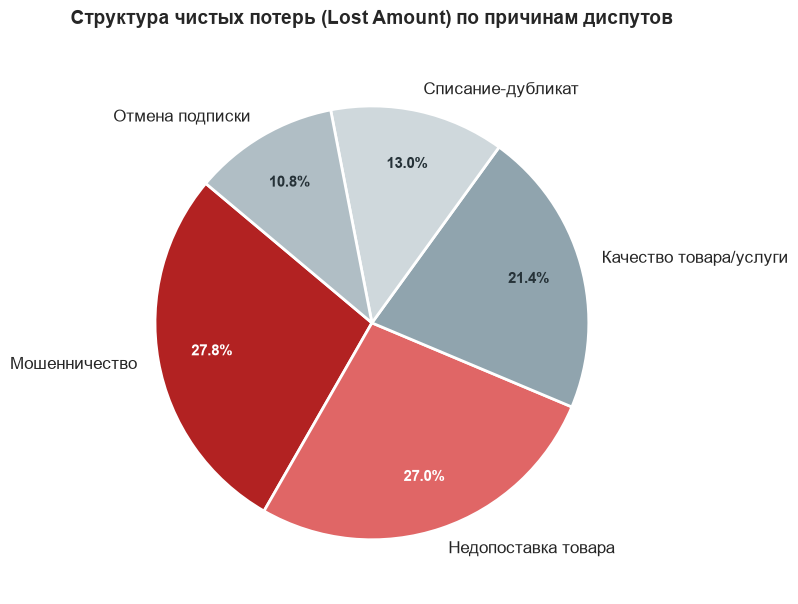

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

df = lost_reason_df.copy()

# Словарь для перевода кодов на русский язык
reason_translation = {
    'fraud': 'Мошенничество',
    'product_not_received': 'Недопоставка товара',
    'quality': 'Качество товара/услуги',
    'subscription_cancel': 'Отмена подписки',
    'duplicate': 'Списание-дубликат'
}
df['reason_ru'] = df['reason_code'].map(reason_translation)

# Сортируем по убыванию для красивого распределения секторов по часовой стрелке
df = df.sort_values(by='lost_amount', ascending=False)

# Настройка строгой бизнес-палитры: фокус на топ-драйверах убытков, остальные — нейтральные
color_mapping = {
    'fraud': '#b22222',                # Firebrick
    'product_not_received': '#e06666', # Смягченный красный
    'quality': '#90a4ae',              # Спокойный серо-синий
    'subscription_cancel': '#b0bec5',  # Светло-серый
    'duplicate': '#cfd8dc'             # Очень светло-серый
}
colors = [color_mapping.get(code, '#eceff1') for code in df['reason_code']]

fig, ax = plt.subplots(figsize=(8, 8))

# Строим круговую диаграмму с отображением только категорий и процентов
wedges, texts, autotexts = ax.pie(
    df['lost_amount'],
    labels=df['reason_ru'],
    autopct='%1.1f%%',              # Выводит только проценты с одним знаком после запятой
    startangle=140,                 # Оптимальный угол поворота стартового сектора
    colors=colors,
    pctdistance=0.75,               # Позиционирование процентов ближе к внешнему краю сектора
    textprops=dict(fontsize=12, weight='medium') # Стилизация названий категорий
)

# Очищаем и стилизуем отображение текста процентов внутри секторов
for idx, autotext in enumerate(autotexts):
    corresponding_code = df['reason_code'].iloc[idx]
    if corresponding_code in ['fraud', 'product_not_received']:
        autotext.set_color('white')
    else:
        autotext.set_color('#263238')

    autotext.set_fontsize(11)
    autotext.set_weight('bold')

# Добавляем тонкие белые разделители между секторами для аккуратности
plt.setp(wedges, edgecolor='white', linewidth=2)

# Корректный заголовок по правилам бизнес-презентаций
plt.title('Структура чистых потерь (Lost Amount) по причинам диспутов',
          fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()

In [39]:
query_lost_category = """
SELECT
    mc.category_name,
    COUNT(*) AS lost_disputes,
    SUM(d.dispute_amount_uzs) AS lost_amount,
    ROUND(AVG(d.dispute_amount_uzs),2) AS avg_lost_amount
FROM public.ds_disputes d
JOIN public.ds_transactions_1 t
    ON d.txn_id = t.txn_id
JOIN public.ds_terminals_1 term
    ON t.terminal_id = term.terminal_id
JOIN public.ds_merchants_1 m
    ON term.merchant_id = m.merchant_id
JOIN public.ds_merchant_categories mc
    ON m.category_id = mc.category_id
WHERE d.status = 'lost'
  AND m.status = 'active'
GROUP BY mc.category_name
ORDER BY lost_amount DESC;
"""

lost_category_df = pd.read_sql(query_lost_category, conn)

lost_category_df

,category_name,lost_disputes,lost_amount,avg_lost_amount
0,Travel,65,60885318.0,936697.20
1,Jewelry,33,38865859.0,1177753.30
2,Hotel,49,31383864.0,640487.02
3,OnlineRetail,82,29270584.0,356958.34
4,Gaming,22,19999418.0,909064.45
5,Restaurant,108,18577701.0,172015.75
6,Electronics,43,11298407.0,262753.65
7,Transport,63,10212447.0,162102.33
8,Marketplace,25,7524128.0,300965.12
9,Telecom,56,7273679.0,129887.13


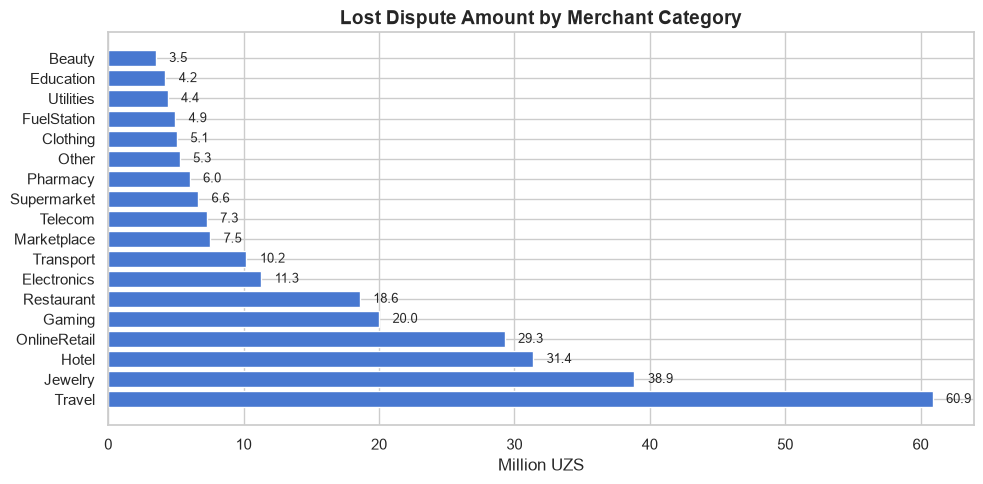

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.barh(
    lost_category_df["category_name"],
    lost_category_df["lost_amount"] / 1e6
)

for bar in bars:
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center",
        fontsize=9
    )

plt.title("Lost Dispute Amount by Merchant Category")
plt.xlabel("Million UZS")

plt.tight_layout()
plt.show()

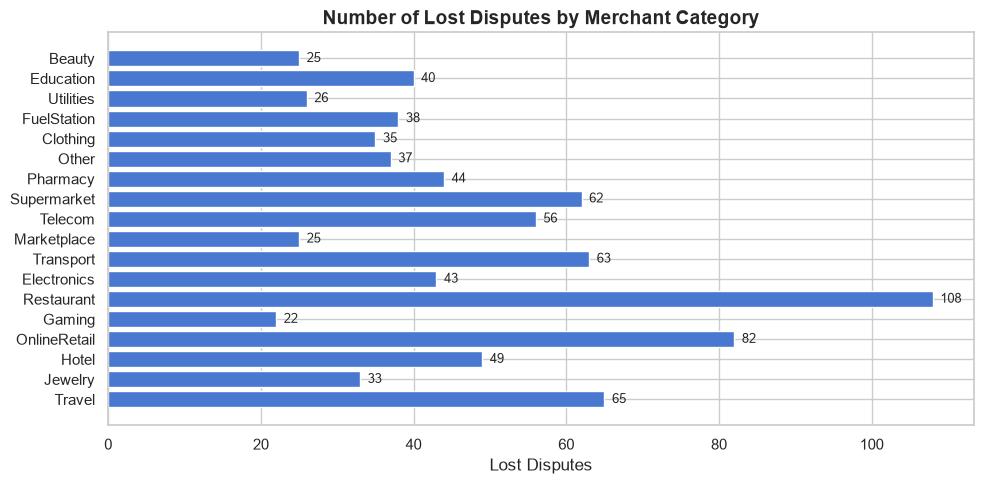

In [41]:
plt.figure(figsize=(10,5))

bars = plt.barh(
    lost_category_df["category_name"],
    lost_category_df["lost_disputes"]
)

for bar in bars:
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va="center",
        fontsize=9
    )

plt.title("Number of Lost Disputes by Merchant Category")
plt.xlabel("Lost Disputes")

plt.tight_layout()
plt.show()

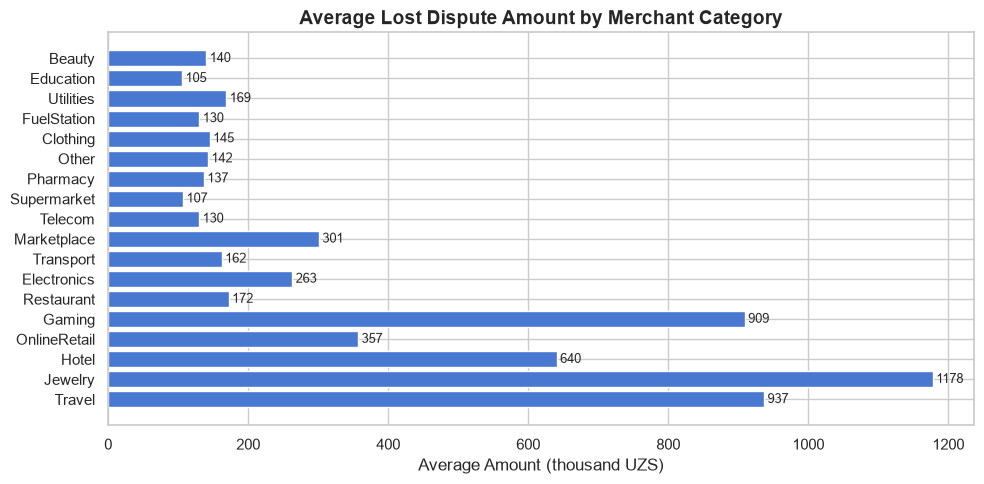

In [42]:
plt.figure(figsize=(10,5))

bars = plt.barh(
    lost_category_df["category_name"],
    lost_category_df["avg_lost_amount"] / 1000
)

for bar in bars:
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.0f}",
        va="center",
        fontsize=9
    )

plt.title("Average Lost Dispute Amount by Merchant Category")
plt.xlabel("Average Amount (thousand UZS)")

plt.tight_layout()
plt.show()

In [43]:
query_lost_rate = """
WITH all_disputes AS (
    SELECT
        mc.category_name,
        COUNT(*) AS total_disputes
    FROM public.ds_disputes d
    JOIN public.ds_transactions_1 t
        ON d.txn_id = t.txn_id
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id
    JOIN public.ds_merchant_categories mc
        ON m.category_id = mc.category_id
    WHERE m.status = 'active'
    GROUP BY mc.category_name
),
lost_disputes AS (
    SELECT
        mc.category_name,
        COUNT(*) AS lost_disputes,
        SUM(d.dispute_amount_uzs) AS lost_amount
    FROM public.ds_disputes d
    JOIN public.ds_transactions_1 t
        ON d.txn_id = t.txn_id
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id
    JOIN public.ds_merchant_categories mc
        ON m.category_id = mc.category_id
    WHERE d.status='lost'
      AND m.status='active'
    GROUP BY mc.category_name
)
SELECT
    a.category_name,
    a.total_disputes,
    l.lost_disputes,
    ROUND(100.0*l.lost_disputes/a.total_disputes,2) AS lost_rate_pct,
    l.lost_amount,
    ROUND(l.lost_amount/l.lost_disputes,2) AS avg_lost_amount
FROM all_disputes a
JOIN lost_disputes l
    ON a.category_name=l.category_name
ORDER BY lost_rate_pct DESC;
"""

lost_rate_df = pd.read_sql(query_lost_rate, conn)

lost_rate_df

,category_name,total_disputes,lost_disputes,lost_rate_pct,lost_amount,avg_lost_amount
0,Gaming,39,22,56.41,19999418.0,909064.45
1,Beauty,47,25,53.19,3501420.0,140056.80
2,Clothing,66,35,53.03,5071307.0,144894.49
3,FuelStation,73,38,52.05,4943688.0,130097.05
4,OnlineRetail,158,82,51.90,29270584.0,356958.34
5,Telecom,111,56,50.45,7273679.0,129887.13
6,Transport,129,63,48.84,10212447.0,162102.33
7,Supermarket,130,62,47.69,6634246.0,107003.97
8,Other,83,37,44.58,5271886.0,142483.41
9,Electronics,102,43,42.16,11298407.0,262753.65


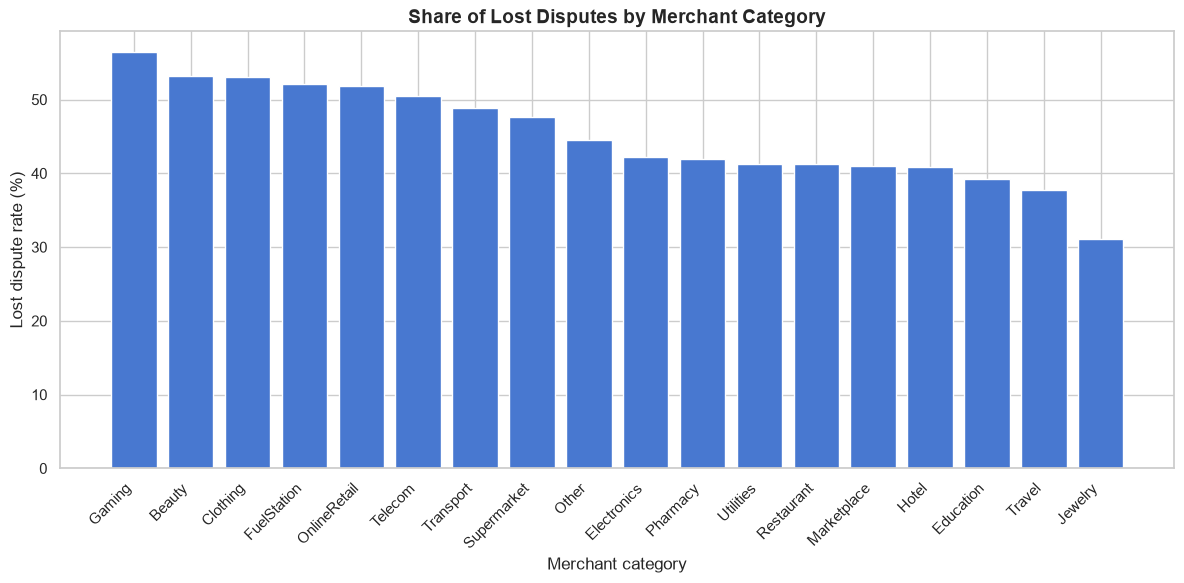

In [44]:
plt.figure(figsize=(12,6))

plt.bar(
    lost_rate_df["category_name"],
    lost_rate_df["lost_rate_pct"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Lost dispute rate (%)")
plt.xlabel("Merchant category")
plt.title("Share of Lost Disputes by Merchant Category")

plt.tight_layout()
plt.show()

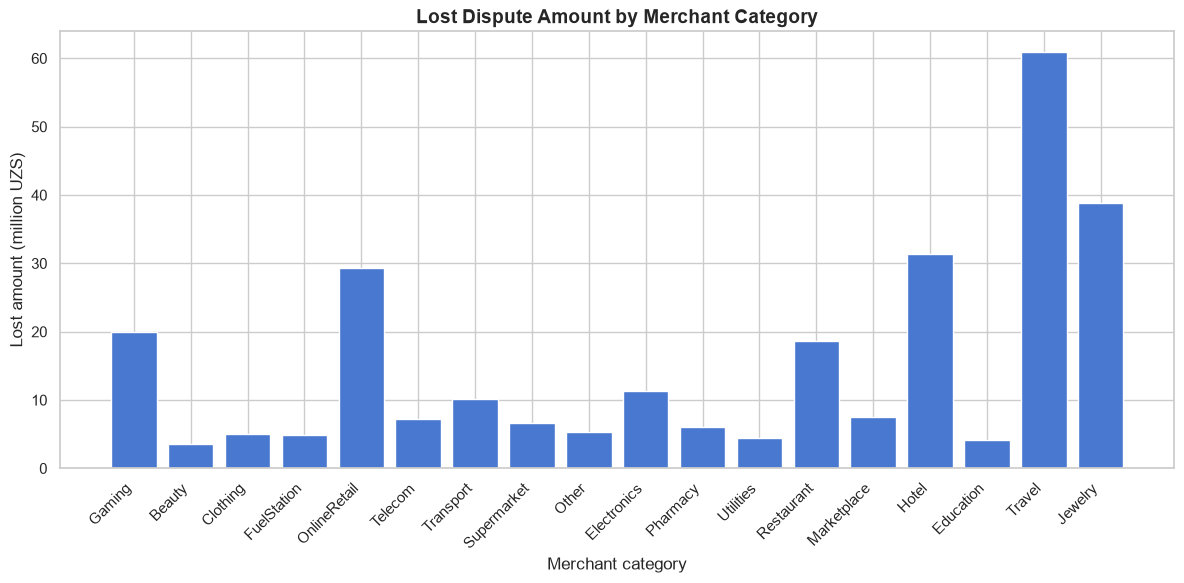

In [45]:
plt.figure(figsize=(12,6))

plt.bar(
    lost_rate_df["category_name"],
    lost_rate_df["lost_amount"]/1e6
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Lost amount (million UZS)")
plt.xlabel("Merchant category")
plt.title("Lost Dispute Amount by Merchant Category")

plt.tight_layout()
plt.show()

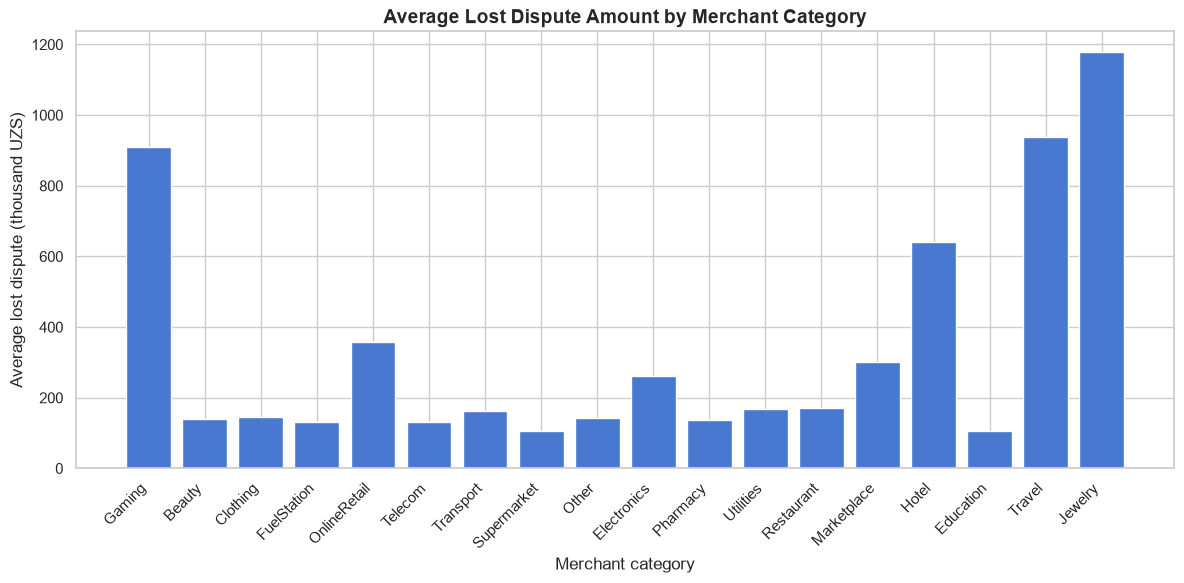

In [46]:
plt.figure(figsize=(12,6))

plt.bar(
    lost_rate_df["category_name"],
    lost_rate_df["avg_lost_amount"]/1000
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Average lost dispute (thousand UZS)")
plt.xlabel("Merchant category")
plt.title("Average Lost Dispute Amount by Merchant Category")

plt.tight_layout()
plt.show()

In [47]:
query_top_merchants = """
WITH merchant_txns AS (
    SELECT
        m.merchant_id,
        m.brand_name,
        mc.category_name,
        m.size_band,
        COUNT(*) AS txn_count,
        SUM(t.amount_uzs) AS turnover_uzs
    FROM public.ds_transactions_1 t
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id
    JOIN public.ds_merchant_categories mc
        ON m.category_id = mc.category_id
    WHERE t.status='approved'
      AND m.status='active'
    GROUP BY
        m.merchant_id,
        m.brand_name,
        mc.category_name,
        m.size_band
),

merchant_disputes AS (
    SELECT
        m.merchant_id,
        COUNT(*) AS disputes_count,
        SUM(d.dispute_amount_uzs) AS disputed_amount_uzs,
        AVG(d.dispute_amount_uzs) AS avg_dispute_amount
    FROM public.ds_disputes d
    JOIN public.ds_transactions_1 t
        ON d.txn_id=t.txn_id
    JOIN public.ds_terminals_1 term
        ON t.terminal_id=term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id=m.merchant_id
    WHERE m.status='active'
    GROUP BY m.merchant_id
)

SELECT
    tx.merchant_id,
    tx.brand_name,
    tx.category_name,
    tx.size_band,
    tx.txn_count,
    COALESCE(dp.disputes_count,0) AS disputes_count,
    ROUND(
        100.0*COALESCE(dp.disputes_count,0)/tx.txn_count,
        2
    ) AS dispute_rate_pct,
    tx.turnover_uzs,
    COALESCE(dp.disputed_amount_uzs,0) AS disputed_amount_uzs,
    ROUND(
        100.0*COALESCE(dp.disputed_amount_uzs,0)/tx.turnover_uzs,
        2
    ) AS disputed_amount_share_pct,
    ROUND(dp.avg_dispute_amount,2) AS avg_dispute_amount
FROM merchant_txns tx
LEFT JOIN merchant_disputes dp
    ON tx.merchant_id=dp.merchant_id
ORDER BY
    dispute_rate_pct DESC,
    disputes_count DESC
LIMIT 20;
"""

merchant_risk_df = pd.read_sql(query_top_merchants, conn)

merchant_risk_df

,merchant_id,brand_name,category_name,size_band,txn_count,disputes_count,dispute_rate_pct,turnover_uzs,disputed_amount_uzs,disputed_amount_share_pct,avg_dispute_amount
0,1021,Brand1021,Travel,micro,15,5,33.33,8626800.0,3571034.0,41.39,714206.8
1,550,Brand550,Hotel,micro,6,2,33.33,3491200.0,898899.0,25.75,449449.5
2,557,Brand557,Transport,micro,9,2,22.22,952700.0,44864.0,4.71,22432.0
3,35,Brand35,Electronics,micro,10,2,20.00,1273000.0,139974.0,11.00,69987.0
4,474,Brand474,Restaurant,micro,11,2,18.18,909500.0,161896.0,17.80,80948.0
5,204,Brand204,Restaurant,micro,11,2,18.18,938000.0,79872.0,8.52,39936.0
6,610,Brand610,Hotel,micro,11,2,18.18,5171700.0,776613.0,15.02,388306.5
7,234,Brand234,Gaming,micro,29,5,17.24,16391100.0,2590987.0,15.81,518197.4
8,378,Brand378,Hotel,small,18,3,16.67,8241200.0,998778.0,12.12,332926.0
9,918,Brand918,Restaurant,micro,12,2,16.67,2054700.0,126211.0,6.14,63105.5


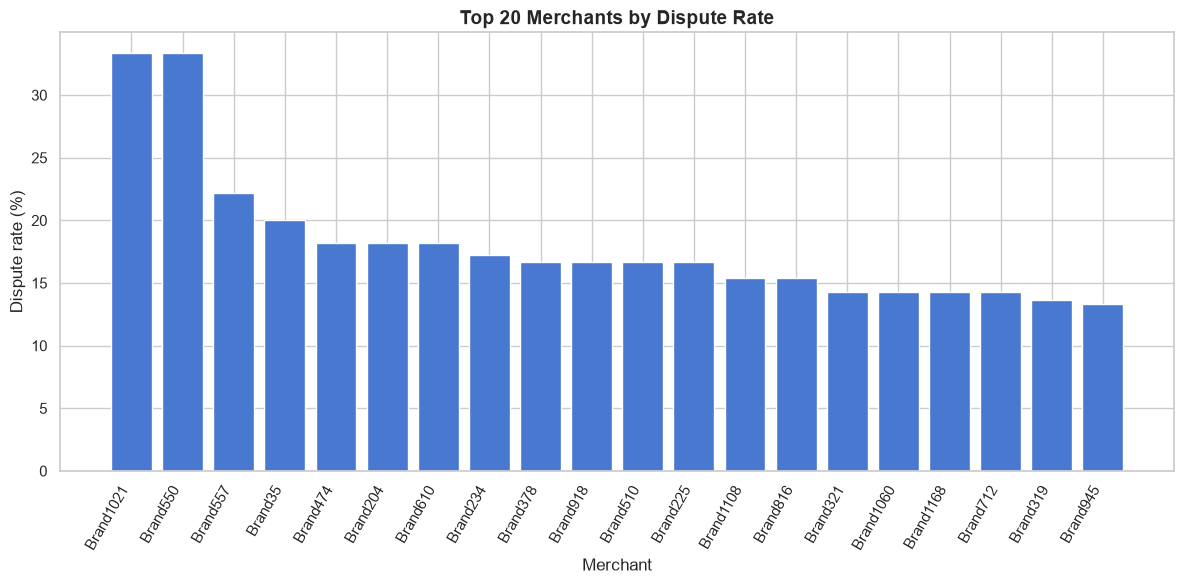

In [48]:
plt.figure(figsize=(12,6))

plt.bar(
    merchant_risk_df["brand_name"],
    merchant_risk_df["dispute_rate_pct"]
)

plt.xticks(rotation=60, ha='right')
plt.ylabel("Dispute rate (%)")
plt.xlabel("Merchant")
plt.title("Top 20 Merchants by Dispute Rate")

plt.tight_layout()
plt.show()

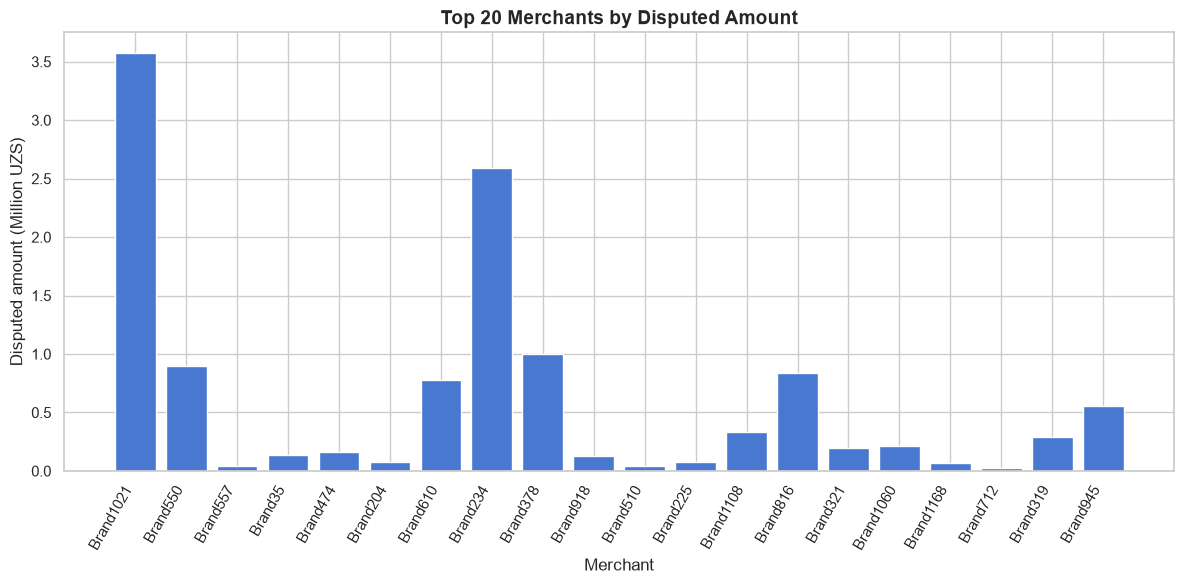

In [49]:
plt.figure(figsize=(12,6))

plt.bar(
    merchant_risk_df["brand_name"],
    merchant_risk_df["disputed_amount_uzs"]/1e6
)

plt.xticks(rotation=60, ha='right')
plt.ylabel("Disputed amount (Million UZS)")
plt.xlabel("Merchant")
plt.title("Top 20 Merchants by Disputed Amount")

plt.tight_layout()
plt.show()

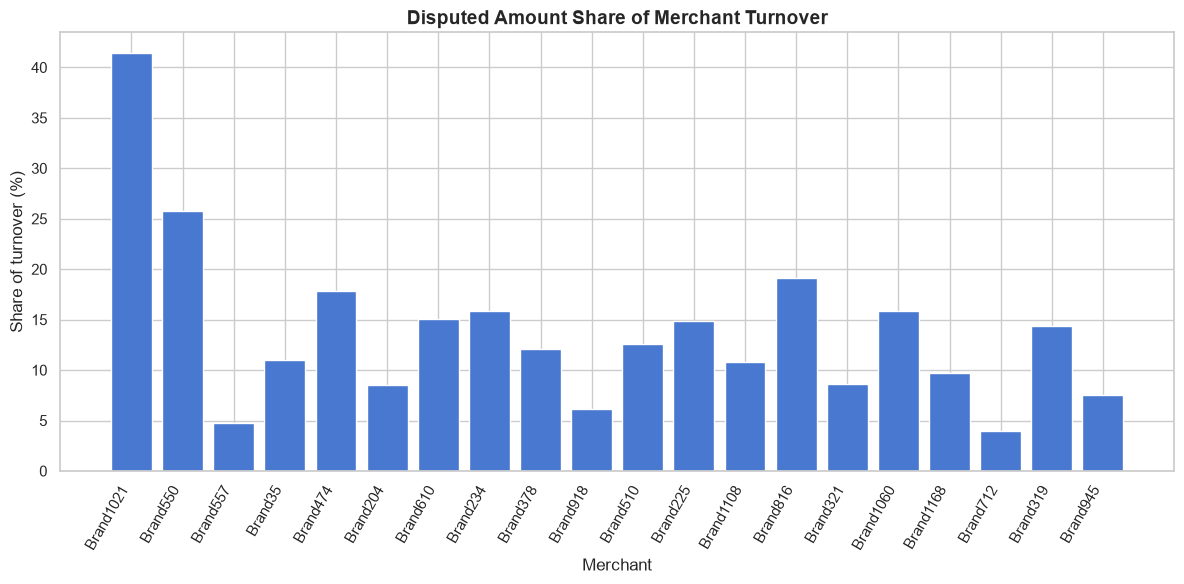

In [50]:
plt.figure(figsize=(12,6))

plt.bar(
    merchant_risk_df["brand_name"],
    merchant_risk_df["disputed_amount_share_pct"]
)

plt.xticks(rotation=60, ha='right')
plt.ylabel("Share of turnover (%)")
plt.xlabel("Merchant")
plt.title("Disputed Amount Share of Merchant Turnover")

plt.tight_layout()
plt.show()

In [51]:
query_merchant_dispute_rate = """
WITH merchant_txns AS (
SELECT
    m.merchant_id,
    m.brand_name,
    COUNT(*) AS total_txns
FROM public.ds_transactions_1 t
JOIN public.ds_terminals_1 term
    ON t.terminal_id = term.terminal_id
JOIN public.ds_merchants_1 m
    ON term.merchant_id = m.merchant_id
WHERE t.status = 'approved'
  AND m.status = 'active'
GROUP BY
    m.merchant_id,
    m.brand_name
),
merchant_disputes AS (
SELECT
    m.merchant_id,
    COUNT(*) AS disputes
FROM public.ds_disputes d
JOIN public.ds_transactions_1 t
    ON d.txn_id = t.txn_id
JOIN public.ds_terminals_1 term
    ON t.terminal_id = term.terminal_id
JOIN public.ds_merchants_1 m
    ON term.merchant_id = m.merchant_id
WHERE m.status = 'active'
GROUP BY
    m.merchant_id
)
SELECT
    mt.merchant_id,
    mt.brand_name,
    mt.total_txns,
    COALESCE(md.disputes,0) AS disputes,
    ROUND(
        100.0 * COALESCE(md.disputes,0) / mt.total_txns,
        2
    ) AS dispute_rate_pct
FROM merchant_txns mt
LEFT JOIN merchant_disputes md
    ON mt.merchant_id = md.merchant_id
WHERE mt.total_txns >= 100
ORDER BY dispute_rate_pct DESC
LIMIT 20;
"""

merchant_dispute_rate_df = pd.read_sql(query_merchant_dispute_rate, conn)

merchant_dispute_rate_df

,merchant_id,brand_name,total_txns,disputes,dispute_rate_pct
0,803,Brand803,129,13,10.08
1,866,Brand866,133,12,9.02
2,110,Brand110,110,9,8.18
3,1120,Brand1120,271,21,7.75
4,502,Brand502,583,42,7.20
5,212,Brand212,940,64,6.81
6,135,Brand135,136,9,6.62
7,662,Brand662,551,35,6.35
8,247,Brand247,211,13,6.16
9,956,Brand956,278,17,6.12


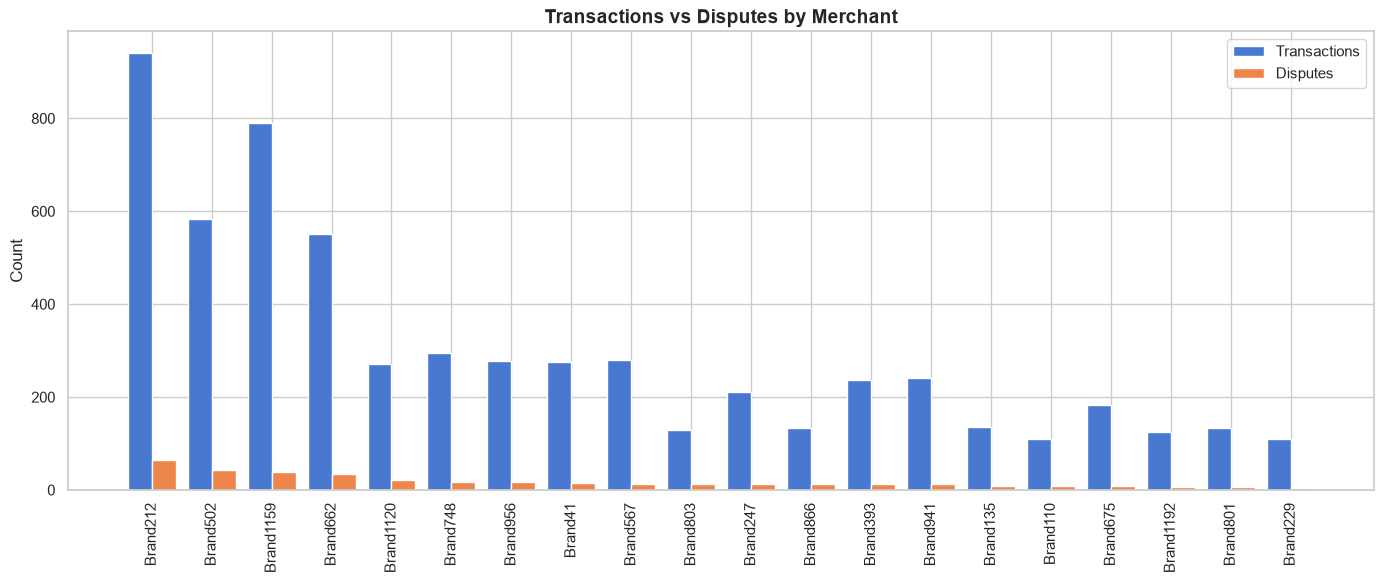

In [52]:
plot_df = merchant_dispute_rate_df.sort_values(
    "disputes",
    ascending=False
)

x = range(len(plot_df))
width = 0.4

plt.figure(figsize=(14,6))

plt.bar(
    [i - width/2 for i in x],
    plot_df["total_txns"],
    width=width,
    label="Transactions"
)

plt.bar(
    [i + width/2 for i in x],
    plot_df["disputes"],
    width=width,
    label="Disputes"
)

plt.xticks(
    x,
    plot_df["brand_name"],
    rotation=90
)

plt.ylabel("Count")
plt.title("Transactions vs Disputes by Merchant")

plt.legend()

plt.tight_layout()
plt.show()

In [53]:
query_merchant_risk = """
WITH merchant_txns AS (
    SELECT
        m.merchant_id,
        m.brand_name,
        mc.category_name,
        m.size_band,
        COUNT(*) AS total_txns
    FROM public.ds_transactions_1 t
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id
    JOIN public.ds_merchant_categories mc
        ON m.category_id = mc.category_id
    WHERE
        t.status = 'approved'
        AND m.status = 'active'
    GROUP BY
        m.merchant_id,
        m.brand_name,
        mc.category_name,
        m.size_band
),
merchant_disputes AS (
    SELECT
        m.merchant_id,
        COUNT(*) AS disputes_count,
        SUM(d.dispute_amount_uzs) AS disputed_amount_uzs,
        AVG(d.dispute_amount_uzs) AS avg_dispute_amount,
        COUNT(*) FILTER (
            WHERE d.status = 'lost'
        ) AS lost_disputes
    FROM public.ds_disputes d
    JOIN public.ds_transactions_1 t
        ON d.txn_id = t.txn_id
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id
    WHERE
        m.status = 'active'
    GROUP BY
        m.merchant_id
)
SELECT
    mt.merchant_id,
    mt.brand_name,
    mt.category_name,
    mt.size_band,
    mt.total_txns,
    COALESCE(md.disputes_count,0) AS disputes_count,
    ROUND(
        100.0 * COALESCE(md.disputes_count,0) / mt.total_txns,
        2
    ) AS dispute_rate_pct,
    ROUND(
        (
            100.0 * COALESCE(md.disputes_count,0) / mt.total_txns
        )
        *
        COALESCE(md.avg_dispute_amount,0)
        / 100000,
        2
    ) AS risk_score,
    COALESCE(md.disputed_amount_uzs,0) AS disputed_amount_uzs,
    ROUND(
        COALESCE(md.avg_dispute_amount,0),
        2
    ) AS avg_dispute_amount,
    COALESCE(md.lost_disputes,0) AS lost_disputes,
    ROUND(
        CASE
            WHEN md.disputes_count > 0
            THEN 100.0 * md.lost_disputes / md.disputes_count
            ELSE 0
        END,
        2
    ) AS lost_rate_pct
FROM merchant_txns mt
LEFT JOIN merchant_disputes md
    ON mt.merchant_id = md.merchant_id
WHERE
    mt.total_txns >= 100
ORDER BY
    risk_score DESC,
    dispute_rate_pct DESC;
"""

merchant_risk_df = pd.read_sql(query_merchant_risk, conn)

merchant_risk_df.head(20)

,merchant_id,brand_name,category_name,size_band,total_txns,disputes_count,dispute_rate_pct,risk_score,disputed_amount_uzs,avg_dispute_amount,lost_disputes,lost_rate_pct
0,803,Brand803,Travel,medium,129,13,10.08,107.58,13877357.0,1067489.00,4,30.77
1,502,Brand502,Travel,large,583,42,7.20,93.90,54741444.0,1303367.71,18,42.86
2,247,Brand247,Gaming,medium,211,13,6.16,79.73,16823677.0,1294129.00,11,84.62
3,212,Brand212,Jewelry,large,940,64,6.81,76.12,71554901.0,1118045.33,20,31.25
4,662,Brand662,Travel,large,551,35,6.35,74.79,41209285.0,1177408.14,15,42.86
5,110,Brand110,Travel,medium,110,9,8.18,72.82,8009924.0,889991.56,4,44.44
6,866,Brand866,Travel,medium,133,12,9.02,71.00,9443243.0,786936.92,4,33.33
7,135,Brand135,Jewelry,medium,136,9,6.62,66.60,9057351.0,1006372.33,3,33.33
8,1159,Brand1159,Hotel,large,791,38,4.80,52.87,41817369.0,1100457.08,14,36.84
9,393,Brand393,Jewelry,medium,236,12,5.08,47.67,11249787.0,937482.25,4,33.33


In [54]:
query_bank_lost_rate = """
SELECT
    dm.settlement_account_bank,
    COUNT(*) AS disputes,
    SUM(
        CASE
            WHEN d.status='lost' THEN 1
            ELSE 0
        END
    ) AS lost,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN d.status='lost' THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS lost_rate
FROM public.ds_disputes d
JOIN public.ds_transactions_1 t
    ON d.txn_id = t.txn_id
JOIN public.ds_settlements s
    ON t.settlement_id = s.settlement_id
JOIN public.ds_merchants_1 dm
    ON s.merchant_id = dm.merchant_id
GROUP BY dm.settlement_account_bank
ORDER BY lost_rate DESC;
"""

bank_lost_rate_df = pd.read_sql(query_bank_lost_rate, conn)

bank_lost_rate_df

,settlement_account_bank,disputes,lost,lost_rate
0,Kapitalbank,432,211,48.84
1,Agrobank,227,103,45.37
2,Aloqabank,219,96,43.84
3,Hamkorbank,271,118,43.54
4,NBU,382,163,42.67
5,Ipoteka,427,178,41.69


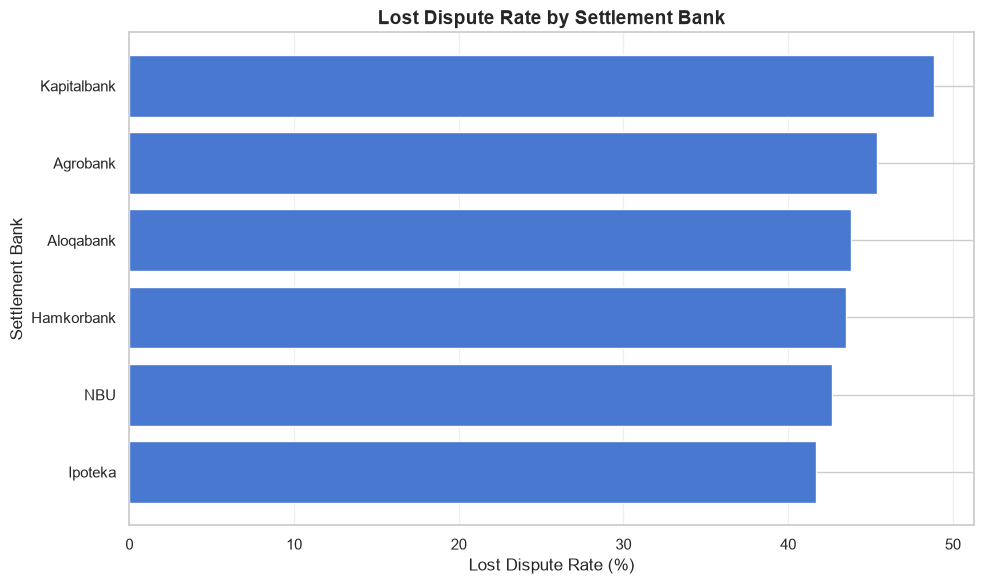

In [55]:
plot_df = bank_lost_rate_df.sort_values("lost_rate")

plt.figure(figsize=(10,6))

plt.barh(
    plot_df["settlement_account_bank"],
    plot_df["lost_rate"]
)

plt.xlabel("Lost Dispute Rate (%)")
plt.ylabel("Settlement Bank")
plt.title("Lost Dispute Rate by Settlement Bank")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

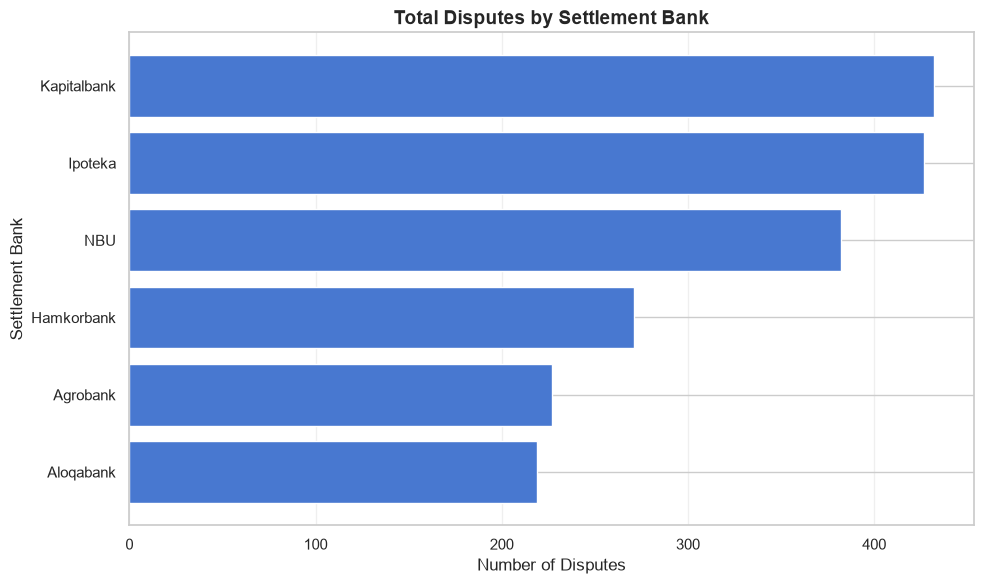

In [56]:
plot_df = bank_lost_rate_df.sort_values("disputes")

plt.figure(figsize=(10,6))

plt.barh(
    plot_df["settlement_account_bank"],
    plot_df["disputes"]
)

plt.xlabel("Number of Disputes")
plt.ylabel("Settlement Bank")
plt.title("Total Disputes by Settlement Bank")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
query_bank_dispute_amount = """
SELECT
    dm.settlement_account_bank,
    AVG(d.dispute_amount_uzs) AS avg_dispute,
    SUM(d.dispute_amount_uzs) AS total_amount
FROM public.ds_disputes d
JOIN public.ds_transactions_1 t
    ON d.txn_id = t.txn_id
JOIN public.ds_settlements s
    ON t.settlement_id = s.settlement_id
JOIN public.ds_merchants_1 dm
    ON s.merchant_id = dm.merchant_id
GROUP BY dm.settlement_account_bank
ORDER BY avg_dispute DESC;
"""

bank_dispute_amount_df = pd.read_sql(query_bank_dispute_amount, conn)

bank_dispute_amount_df

,settlement_account_bank,avg_dispute,total_amount
0,NBU,393396.714660,150277545.0
1,Kapitalbank,390060.372685,168506081.0
2,Agrobank,369375.008811,83848127.0
3,Aloqabank,317832.703196,69605362.0
4,Ipoteka,295398.334895,126135089.0
5,Hamkorbank,255919.464945,69354175.0


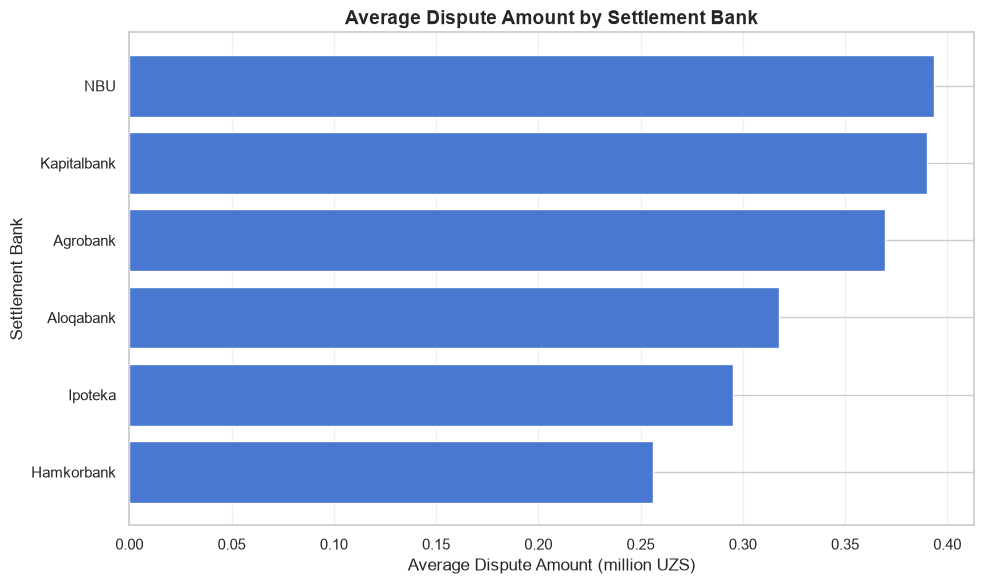

In [58]:
import matplotlib.pyplot as plt

plot_df = bank_dispute_amount_df.sort_values("avg_dispute")

plt.figure(figsize=(10,6))

plt.barh(
    plot_df["settlement_account_bank"],
    plot_df["avg_dispute"] / 1e6
)

plt.xlabel("Average Dispute Amount (million UZS)")
plt.ylabel("Settlement Bank")
plt.title("Average Dispute Amount by Settlement Bank")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
query_loss_rate = """
WITH turnover AS (
    SELECT
        m.merchant_id,
        m.brand_name,
        m.size_band,
        mc.category_name,
        SUM(t.amount_uzs) AS turnover_uzs
    FROM public.ds_transactions_1 t
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id
    JOIN public.ds_merchant_categories mc
        ON m.category_id = mc.category_id
    WHERE t.status = 'approved'
    GROUP BY
        m.merchant_id,
        m.brand_name,
        m.size_band,
        mc.category_name
),
lost_disputes AS (
    SELECT
        term.merchant_id,
        COUNT(*) AS lost_count,
        SUM(d.dispute_amount_uzs) AS lost_amount
    FROM public.ds_disputes d
    JOIN public.ds_transactions_1 t
        ON d.txn_id = t.txn_id
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    WHERE d.status = 'lost'
      AND t.status = 'approved'
    GROUP BY term.merchant_id
)
SELECT
    tr.merchant_id,
    tr.brand_name,
    tr.category_name,
    tr.size_band,
    tr.turnover_uzs,
    COALESCE(ld.lost_count,0) AS lost_disputes,
    COALESCE(ld.lost_amount,0) AS lost_amount,
    ROUND(
        100.0 * COALESCE(ld.lost_amount,0) / tr.turnover_uzs,
        4
    ) AS loss_rate_pct
FROM turnover tr
LEFT JOIN lost_disputes ld
    ON tr.merchant_id = ld.merchant_id
WHERE tr.turnover_uzs >= 100000000
ORDER BY loss_rate_pct DESC;
"""

merchant_loss_df = pd.read_sql(query_loss_rate, conn)

merchant_loss_df.head()

,merchant_id,brand_name,category_name,size_band,turnover_uzs,lost_disputes,lost_amount,loss_rate_pct
0,247,Brand247,Gaming,medium,223222700.0,11,14401558.0,6.4517
1,110,Brand110,Travel,medium,117290400.0,4,4217896.0,3.5961
2,135,Brand135,Jewelry,medium,131344000.0,3,4553722.0,3.4670
3,502,Brand502,Travel,large,930973100.0,18,23800636.0,2.5565
4,844,Brand844,OnlineRetail,medium,109736300.0,6,2380253.0,2.1691


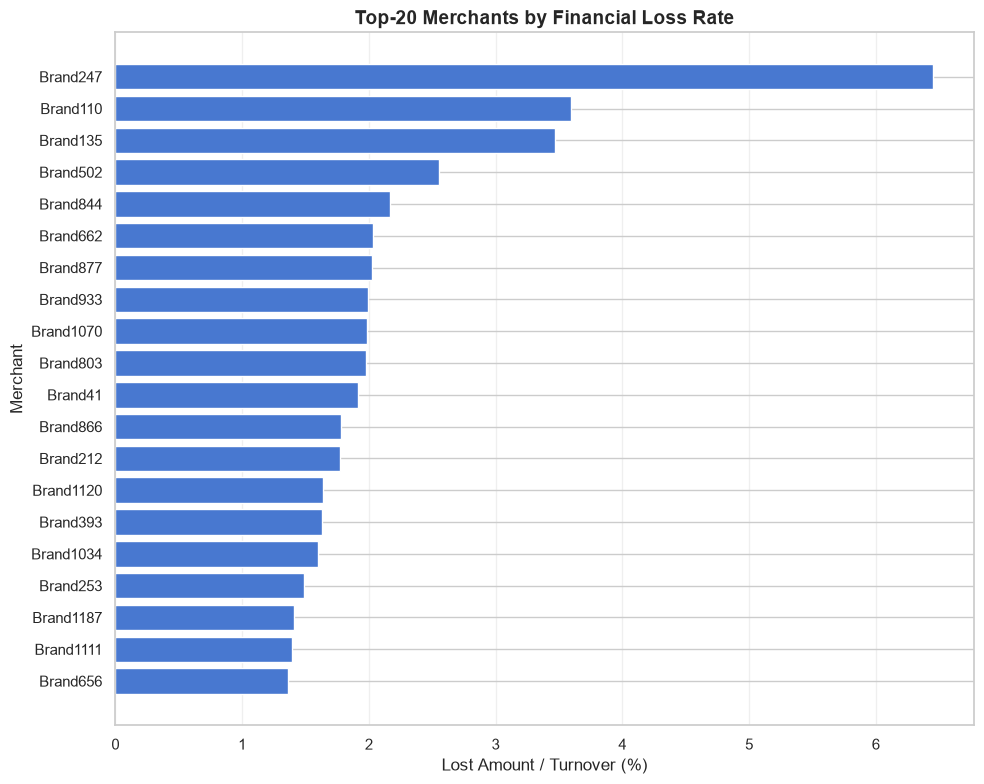

In [60]:
top20 = (
    merchant_loss_df
    .head(20)
    .sort_values("loss_rate_pct")
)

plt.figure(figsize=(10,8))

plt.barh(
    top20["brand_name"],
    top20["loss_rate_pct"]
)

plt.xlabel("Lost Amount / Turnover (%)")
plt.ylabel("Merchant")
plt.title("Top-20 Merchants by Financial Loss Rate")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
sql("""
WITH category_disputes AS (
    SELECT
        mc.category_name,
        d.dispute_id,
        d.dispute_amount_uzs,
        d.status
    FROM ds_disputes d
    JOIN ds_transactions_1 t       ON d.txn_id         = t.txn_id
    JOIN ds_terminals_1 term       ON t.terminal_id    = term.terminal_id
    JOIN ds_merchants_1 m          ON term.merchant_id = m.merchant_id
    JOIN ds_merchant_categories mc ON m.category_id    = mc.category_id
)
SELECT
    category_name,
    COUNT(*)                                                              AS total_disputes,
    COUNT(*) FILTER (WHERE status = 'lost')                               AS lost_disputes,
    ROUND(100.0 * COUNT(*) FILTER (WHERE status = 'lost') / COUNT(*), 2)  AS lost_rate_pct,
    ROUND(AVG(dispute_amount_uzs) FILTER (WHERE status = 'lost'), 0)      AS avg_lost_amount_uzs,
    SUM(dispute_amount_uzs) FILTER (WHERE status = 'lost')                AS total_lost_amount_uzs
FROM category_disputes
GROUP BY category_name
ORDER BY total_lost_amount_uzs DESC;
""")

,category_name,total_disputes,lost_disputes,lost_rate_pct,avg_lost_amount_uzs,total_lost_amount_uzs
0,Travel,173,65,37.57,936697.0,60885318.0
1,Jewelry,107,33,30.84,1177753.0,38865859.0
2,Hotel,124,51,41.13,636195.0,32445929.0
3,OnlineRetail,160,83,51.88,354256.0,29403227.0
4,Gaming,39,22,56.41,909064.0,19999418.0
5,Restaurant,264,110,41.67,169644.0,18660855.0
6,Electronics,104,44,42.31,259159.0,11403016.0
7,Transport,129,63,48.84,162102.0,10212447.0
8,Marketplace,64,27,42.19,339092.0,9155496.0
9,Telecom,115,58,50.43,130718.0,7581639.0


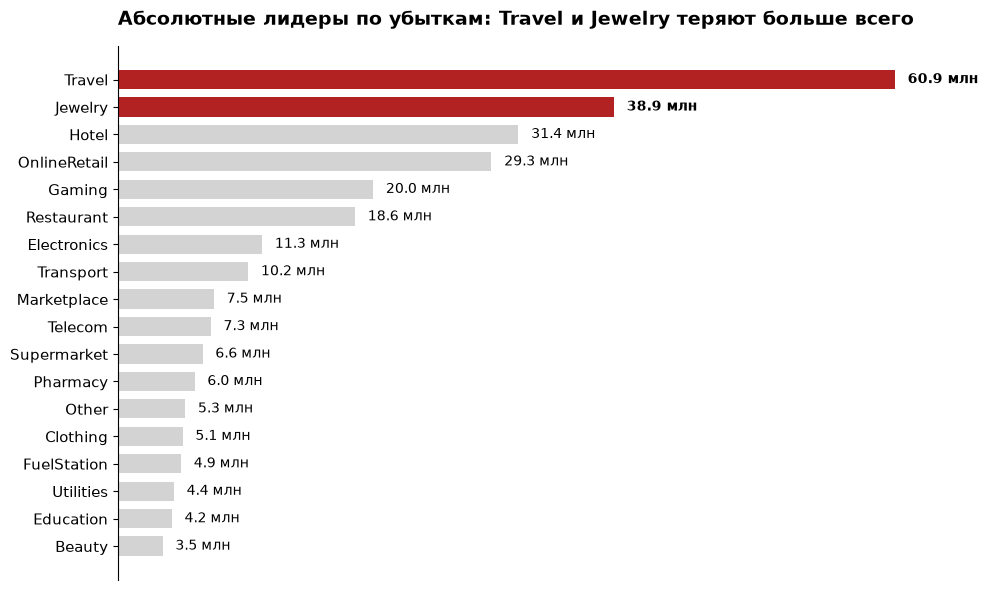

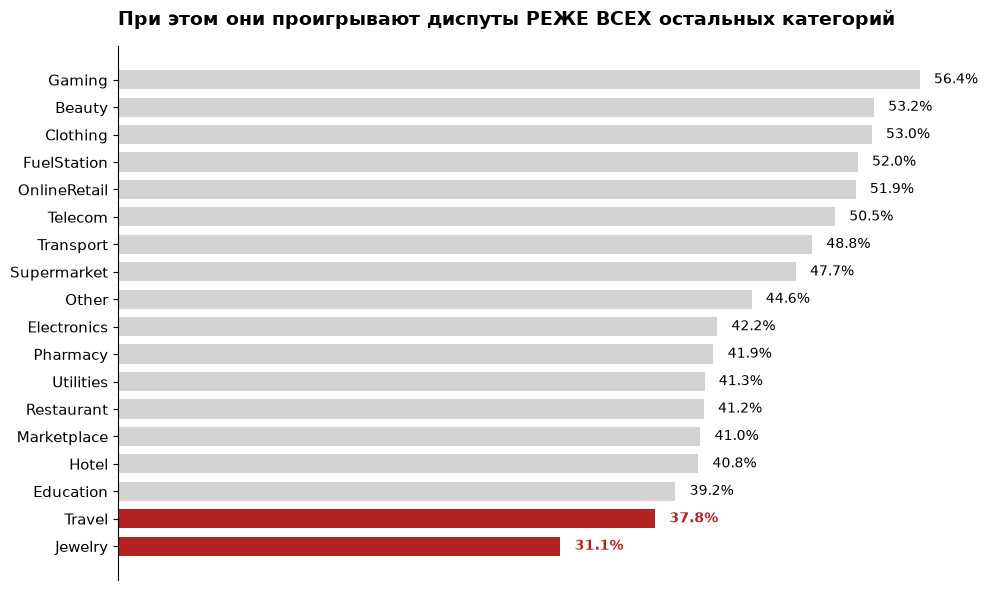

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Загрузка данных
df = pd.read_csv('../exports/Cell output 50 [DW].csv')
target_categories = ['Travel', 'Jewelry']

# =========================================================
# ГРАФИК 1: Потерянные деньги (Сортируем по сумме денег)
# =========================================================
# Сортируем так, чтобы самая большая сумма оказалась в топе (ascending=True для barh)
df_money = df.sort_values(by='lost_amount', ascending=True).reset_index(drop=True)
colors_money = ['firebrick' if cat in target_categories else 'lightgray' for cat in df_money['category_name']]

plt.figure(figsize=(10, 6))
bars1 = plt.barh(df_money['category_name'], df_money['lost_amount'] / 1e6, color=colors_money, height=0.7)

# Добавляем значения прям на график
for i, bar in enumerate(bars1):
    val = bar.get_width()
    fw = 'bold' if df_money['category_name'].iloc[i] in target_categories else 'normal'
    plt.text(val + 1.0, bar.get_y() + bar.get_height()/2, f'{val:.1f} млн',
             va='center', color='black', fontsize=10, weight=fw)

# Настройка осей и красоты для первого графика
plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
plt.gca().xaxis.set_visible(False)
plt.yticks(fontsize=11)
plt.title('Абсолютные лидеры по убыткам: Travel и Jewelry теряют больше всего',
          fontsize=14, weight='bold', loc='left', pad=15)
plt.tight_layout()
plt.show()

print('\n') # Пробел между графиками для наглядности в тетрадке

# =========================================================
# ГРАФИК 2: Процент проигранных споров (Сортируем по проценту)
# =========================================================
# Сортируем так, чтобы самые большие % были сверху, а самые низкие (Travel/Jewelry) — упали вниз
df_rate = df.sort_values(by='lost_rate_pct', ascending=True).reset_index(drop=True)
colors_rate = ['firebrick' if cat in target_categories else 'lightgray' for cat in df_rate['category_name']]

plt.figure(figsize=(10, 6))
bars2 = plt.barh(df_rate['category_name'], df_rate['lost_rate_pct'], color=colors_rate, height=0.7)

# Добавляем значения
for i, bar in enumerate(bars2):
    val = bar.get_width()
    fw = 'bold' if df_rate['category_name'].iloc[i] in target_categories else 'normal'
    tc = 'firebrick' if df_rate['category_name'].iloc[i] in target_categories else 'black'
    plt.text(val + 1.0, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
             va='center', color=tc, fontsize=10, weight=fw)

# Настройка осей и красоты для второго графика
plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
plt.gca().xaxis.set_visible(False)
plt.yticks(fontsize=11)
plt.title('При этом они проигрывают диспуты РЕЖЕ ВСЕХ остальных категорий',
          fontsize=14, weight='bold', loc='left', pad=15)
plt.tight_layout()
plt.show()

# Общий Вывод по Гипотезе 3

## Бизнес-контекст

* **Ситуация (Situation):** MerchantHub развивает платежные сервисы. При росте объемов продаж компания неизбежно сталкивается со спорами (диспутами) со стороны покупателей, которые требуют вернуть деньги за покупки.
* **Осложнение (Complication):** Входящие споры создают операционную нагрузку, замораживают оборот платформы и превращаются в прямые невозвратные убытки компании, если комплаенс-отдел проигрывает дело.
* **Вопрос (Question):** Действительно ли риски появления споров и реальные денежные потери распределены по платформе равномерно и зависят только от общего объема продаж торговых точек?
* **Ответ (Answer / Главный вывод):** Первичная гипотеза полностью опровергнута. Финансовые риски жестко сконцентрированы: всего две операционные причины («Мошенничество» и «Недопоставка») и один банк-партнер (Kapitalbank) формируют основную массу чистых потерь компании.

---

## Сводные аналитические данные по исходам споров

Данные отражают структуру распределения финансовых исходов по всем зафиксированным диспутам внутри контура MerchantHub:

| Статус спора | Количество дел | Доля от всех дел | Сумма споров (UZS) | Доля от всех денег |
| --- | --- | --- | --- | --- |
| **Выиграно (Won)** | 803 | 41.63% | 298.51 млн | 44.95% |
| **Проиграно (Lost)** | 879 | 45.57% | 281.30 млн | 42.36% |
| **В процессе (Open)** | 304 | 12.80% | 97.44 млн | 12.69% |
| **Итого по спорам** | **1 929** | **100%** | **664.12 млн** | **100%** |

* **Системные маркеры (Red-line):** Общий уровень споров удерживается на безопасной отметке — **2.73%** от количества транзакций (или **2.89%** от денежного оборота платформы). Однако средний процент проигранных дел зафиксирован на высоком уровне — **45.57%**.

---

## Разбор находки

* **Главные триггеры убытков:** Прямые потери компании не размазаны по категориям случайно. Основной объем чистых потерь (281.30 млн UZS) уходит по двум конкретным причинам — фрод («Мошенничество») и логистические сбои («Недопоставка товара»).
* **Выявление банковской аномалии:** Опровергнуто предположение о равной надежности банков-эквайеров. Выявлена критическая уязвимость в контуре **Kapitalbank**. Он лидирует с огромным отрывом как по числу споров (432 дела), так и по доле проигрышей — комплаенс-служба теряет в нем **48.84%** всех оспариваемых денег (проигран 211 спор). Для сравнения, у остальных пяти банков (NBU, Ipoteka, Hamkorbank и др.) этот показатель держится в пределах 41–45%.
* **Фактор высокого чека:** Опасность напрямую связана со спецификой бизнеса мерчанта. Самые крупные суммы споров генерируют категории с традиционно высоким чеком — `Travel` (Путешествия) и `Jewelry` (Ювелирные изделия). Они требуют внедрения превентивного скоринга транзакций на стороне MerchantHub.
* **Риск незавершенных дел:** Прямо сейчас в процессе рассмотрения находятся еще **304 спора** на сумму **97.44 млн UZS**. Их финальный исход пока не определен, но в худшем случае он способен увеличить текущие чистые потери компании еще максимум на треть.